In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
test = pd.read_csv('/kaggle/input/playground-series-s3e20/test.csv')
test.head()

,ID_LAT_LON_YEAR_WEEK,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,SulphurDioxide_sensor_zenith_angle,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_solar_zenith_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,CarbonMonoxide_cloud_height,CarbonMonoxide_sensor_altitude,CarbonMonoxide_sensor_azimuth_angle,CarbonMonoxide_sensor_zenith_angle,CarbonMonoxide_solar_azimuth_angle,CarbonMonoxide_solar_zenith_angle,NitrogenDioxide_NO2_column_number_density,NitrogenDioxide_tropospheric_NO2_column_number_density,NitrogenDioxide_stratospheric_NO2_column_number_density,NitrogenDioxide_NO2_slant_column_number_density,NitrogenDioxide_tropopause_pressure,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_sensor_altitude,NitrogenDioxide_sensor_azimuth_angle,NitrogenDioxide_sensor_zenith_angle,NitrogenDioxide_solar_azimuth_angle,NitrogenDioxide_solar_zenith_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_cloud_fraction,Formaldehyde_solar_zenith_angle,Formaldehyde_solar_azimuth_angle,Formaldehyde_sensor_zenith_angle,Formaldehyde_sensor_azimuth_angle,UvAerosolIndex_absorbing_aerosol_index,UvAerosolIndex_sensor_altitude,UvAerosolIndex_sensor_azimuth_angle,UvAerosolIndex_sensor_zenith_angle,UvAerosolIndex_solar_azimuth_angle,UvAerosolIndex_solar_zenith_angle,Ozone_O3_column_number_density,Ozone_O3_column_number_density_amf,Ozone_O3_slant_column_number_density,Ozone_O3_effective_temperature,Ozone_cloud_fraction,Ozone_sensor_azimuth_angle,Ozone_sensor_zenith_angle,Ozone_solar_azimuth_angle,Ozone_solar_zenith_angle,UvAerosolLayerHeight_aerosol_height,UvAerosolLayerHeight_aerosol_pressure,UvAerosolLayerHeight_aerosol_optical_depth,UvAerosolLayerHeight_sensor_zenith_angle,UvAerosolLayerHeight_sensor_azimuth_angle,UvAerosolLayerHeight_solar_azimuth_angle,UvAerosolLayerHeight_solar_zenith_angle,Cloud_cloud_fraction,Cloud_cloud_top_pressure,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle
0,ID_-0.510_29.290_2022_00,-0.51,29.29,2022,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.561522,829937.000000,-100.113785,33.696957,-133.047562,33.779572,0.112175,2.374888,0.269846,227.193100,0.485340,-100.113785,33.696957,-133.047562,33.779572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.485129,36022.027344,8472.313477,41047.937500,7472.313477,7.935617,0.240773,-100.113792,33.697044,-133.047546,33.779583
1,ID_-0.510_29.290_2022_01,-0.51,29.29,2022,1,0.000456,0.691164,0.000316,0.000000,76.239196,15.600607,-140.529848,28.896124,0.000157,0.037641,1688.656342,2814.309683,829652.957598,26.072167,25.189549,-142.612636,28.318923,0.000048,1.117653e-05,0.000037,0.000093,7311.869141,-1.416309,0.036769,829736.125000,76.239196,15.600607,-140.529848,28.896124,0.000123,0.957096,0.000058,0.000000,28.896124,-140.529848,15.600607,76.239196,-0.823662,829753.051343,-0.009998,34.745542,-139.171039,30.405075,0.112643,2.537305,0.290184,228.489219,0.515679,-0.009998,34.745542,-139.171039,30.405075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.711262,48539.737242,6476.147323,54915.708579,5476.147161,11.448437,0.293119,-30.510319,42.402593,-138.632822,31.012380
2,ID_-0.510_29.290_2022_02,-0.51,29.29,2022,2,0.000161,0.605107,0.000106,0.079870,-42.055341,39.889060,-136.908976,30.054682,0.000053,0.037795,2629.692089,3233.654973,829589.971617,14.881259,40.833582,-143.949340,26.760219,0.000055,1.679787e-05,0.000038,0.000109,8

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s3e20/train.csv')
train.head()

,ID_LAT_LON_YEAR_WEEK,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,SulphurDioxide_sensor_zenith_angle,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_solar_zenith_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,CarbonMonoxide_cloud_height,CarbonMonoxide_sensor_altitude,CarbonMonoxide_sensor_azimuth_angle,CarbonMonoxide_sensor_zenith_angle,CarbonMonoxide_solar_azimuth_angle,CarbonMonoxide_solar_zenith_angle,NitrogenDioxide_NO2_column_number_density,NitrogenDioxide_tropospheric_NO2_column_number_density,NitrogenDioxide_stratospheric_NO2_column_number_density,NitrogenDioxide_NO2_slant_column_number_density,NitrogenDioxide_tropopause_pressure,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_sensor_altitude,NitrogenDioxide_sensor_azimuth_angle,NitrogenDioxide_sensor_zenith_angle,NitrogenDioxide_solar_azimuth_angle,NitrogenDioxide_solar_zenith_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_cloud_fraction,Formaldehyde_solar_zenith_angle,Formaldehyde_solar_azimuth_angle,Formaldehyde_sensor_zenith_angle,Formaldehyde_sensor_azimuth_angle,UvAerosolIndex_absorbing_aerosol_index,UvAerosolIndex_sensor_altitude,UvAerosolIndex_sensor_azimuth_angle,UvAerosolIndex_sensor_zenith_angle,UvAerosolIndex_solar_azimuth_angle,UvAerosolIndex_solar_zenith_angle,Ozone_O3_column_number_density,Ozone_O3_column_number_density_amf,Ozone_O3_slant_column_number_density,Ozone_O3_effective_temperature,Ozone_cloud_fraction,Ozone_sensor_azimuth_angle,Ozone_sensor_zenith_angle,Ozone_solar_azimuth_angle,Ozone_solar_zenith_angle,UvAerosolLayerHeight_aerosol_height,UvAerosolLayerHeight_aerosol_pressure,UvAerosolLayerHeight_aerosol_optical_depth,UvAerosolLayerHeight_sensor_zenith_angle,UvAerosolLayerHeight_sensor_azimuth_angle,UvAerosolLayerHeight_solar_azimuth_angle,UvAerosolLayerHeight_solar_zenith_angle,Cloud_cloud_fraction,Cloud_cloud_top_pressure,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle,emission
0,ID_-0.510_29.290_2019_00,-0.51,29.29,2019,0,-0.000108,0.603019,-0.000065,0.255668,-98.593887,50.843559,-130.050797,35.874496,-0.000027,0.035370,1589.024536,4061.098145,829530.500000,71.111977,52.775928,-149.875565,25.965214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000117,0.863230,0.000038,0.255668,35.874496,-130.050797,50.843559,-98.593887,-1.280761,829864.546875,-12.628979,35.632416,-138.786446,30.752128,0.115927,2.506609,0.295663,225.731144,0.595473,-12.628979,35.632416,-138.786446,30.752128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.595473,53534.732422,3664.436218,61085.809570,2615.120483,15.568533,0.272292,-12.628986,35.632416,-138.786423,30.752140,3.750994
1,ID_-0.510_29.290_2019_01,-0.51,29.29,2019,1,0.000021,0.728214,0.000014,0.130988,16.592861,39.137194,-140.874435,28.965133,0.000012,0.036526,1772.574405,1869.040414,829787.287130,-1.019594,38.982368,-140.158048,29.562000,0.000047,1.639765e-05,0.00003,0.000093,7311.869141,-1.935386,0.067038,829859.960368,5.471037,35.265195,-138.343908,30.054262,0.000170,1.172826,0.000143,0.200754,29.071781,-141.814827,43.050213,4.678839,-1.548119,829747.856973,16.152492,43.485327,-142.786141,28.573627,0.116775,2.657704,0.315733,226.172170,0.175166,24.464335,42.596541,-143.097868,28.213655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.213608,63790.296241,3651.190311,66969.478735,3174.572424,8.690601,0.256830,30.359375,39.557633,-145.183930,27.251779,4.025176
2,ID_-0.510_29.290_2019_02,-0.51,29.29,2019,2,0.000514,0.748199,0.000385,0.110018,72.

In [4]:
combined = pd.concat([train,test])
combined.head()

,ID_LAT_LON_YEAR_WEEK,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,SulphurDioxide_sensor_zenith_angle,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_solar_zenith_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,CarbonMonoxide_cloud_height,CarbonMonoxide_sensor_altitude,CarbonMonoxide_sensor_azimuth_angle,CarbonMonoxide_sensor_zenith_angle,CarbonMonoxide_solar_azimuth_angle,CarbonMonoxide_solar_zenith_angle,NitrogenDioxide_NO2_column_number_density,NitrogenDioxide_tropospheric_NO2_column_number_density,NitrogenDioxide_stratospheric_NO2_column_number_density,NitrogenDioxide_NO2_slant_column_number_density,NitrogenDioxide_tropopause_pressure,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_sensor_altitude,NitrogenDioxide_sensor_azimuth_angle,NitrogenDioxide_sensor_zenith_angle,NitrogenDioxide_solar_azimuth_angle,NitrogenDioxide_solar_zenith_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_cloud_fraction,Formaldehyde_solar_zenith_angle,Formaldehyde_solar_azimuth_angle,Formaldehyde_sensor_zenith_angle,Formaldehyde_sensor_azimuth_angle,UvAerosolIndex_absorbing_aerosol_index,UvAerosolIndex_sensor_altitude,UvAerosolIndex_sensor_azimuth_angle,UvAerosolIndex_sensor_zenith_angle,UvAerosolIndex_solar_azimuth_angle,UvAerosolIndex_solar_zenith_angle,Ozone_O3_column_number_density,Ozone_O3_column_number_density_amf,Ozone_O3_slant_column_number_density,Ozone_O3_effective_temperature,Ozone_cloud_fraction,Ozone_sensor_azimuth_angle,Ozone_sensor_zenith_angle,Ozone_solar_azimuth_angle,Ozone_solar_zenith_angle,UvAerosolLayerHeight_aerosol_height,UvAerosolLayerHeight_aerosol_pressure,UvAerosolLayerHeight_aerosol_optical_depth,UvAerosolLayerHeight_sensor_zenith_angle,UvAerosolLayerHeight_sensor_azimuth_angle,UvAerosolLayerHeight_solar_azimuth_angle,UvAerosolLayerHeight_solar_zenith_angle,Cloud_cloud_fraction,Cloud_cloud_top_pressure,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle,emission
0,ID_-0.510_29.290_2019_00,-0.51,29.29,2019,0,-0.000108,0.603019,-0.000065,0.255668,-98.593887,50.843559,-130.050797,35.874496,-0.000027,0.035370,1589.024536,4061.098145,829530.500000,71.111977,52.775928,-149.875565,25.965214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000117,0.863230,0.000038,0.255668,35.874496,-130.050797,50.843559,-98.593887,-1.280761,829864.546875,-12.628979,35.632416,-138.786446,30.752128,0.115927,2.506609,0.295663,225.731144,0.595473,-12.628979,35.632416,-138.786446,30.752128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.595473,53534.732422,3664.436218,61085.809570,2615.120483,15.568533,0.272292,-12.628986,35.632416,-138.786423,30.752140,3.750994
1,ID_-0.510_29.290_2019_01,-0.51,29.29,2019,1,0.000021,0.728214,0.000014,0.130988,16.592861,39.137194,-140.874435,28.965133,0.000012,0.036526,1772.574405,1869.040414,829787.287130,-1.019594,38.982368,-140.158048,29.562000,0.000047,1.639765e-05,0.00003,0.000093,7311.869141,-1.935386,0.067038,829859.960368,5.471037,35.265195,-138.343908,30.054262,0.000170,1.172826,0.000143,0.200754,29.071781,-141.814827,43.050213,4.678839,-1.548119,829747.856973,16.152492,43.485327,-142.786141,28.573627,0.116775,2.657704,0.315733,226.172170,0.175166,24.464335,42.596541,-143.097868,28.213655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.213608,63790.296241,3651.190311,66969.478735,3174.572424,8.690601,0.256830,30.359375,39.557633,-145.183930,27.251779,4.025176
2,ID_-0.510_29.290_2019_02,-0.51,29.29,2019,2,0.000514,0.748199,0.000385,0.110018,72.

In [8]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 103376 entries, 0 to 24352
Data columns (total 76 columns):
 #   Column                                                    Non-Null Count   Dtype  
---  ------                                                    --------------   -----  
 0   ID_LAT_LON_YEAR_WEEK                                      103376 non-null  object 
 1   latitude                                                  103376 non-null  float64
 2   longitude                                                 103376 non-null  float64
 3   year                                                      103376 non-null  int64  
 4   week_no                                                   103376 non-null  int64  
 5   SulphurDioxide_SO2_column_number_density                  82625 non-null   float64
 6   SulphurDioxide_SO2_column_number_density_amf              82625 non-null   float64
 7   SulphurDioxide_SO2_slant_column_number_density            82625 non-null   float64
 8   Sulph

In [9]:
combined.dtypes

ID_LAT_LON_YEAR_WEEK           object
latitude                      float64
longitude                     float64
year                            int64
week_no                         int64
                               ...   
Cloud_sensor_azimuth_angle    float64
Cloud_sensor_zenith_angle     float64
Cloud_solar_azimuth_angle     float64
Cloud_solar_zenith_angle      float64
emission                      float64
Length: 76, dtype: object

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,103376.0,-1.891072,0.694521,-3.299000,-2.451000,-1.882000,-1.303000,-0.510000
longitude,103376.0,29.880155,0.810374,28.228000,29.262000,29.883000,30.471000,31.532000
year,103376.0,2020.471154,1.109031,2019.000000,2019.000000,2020.000000,2021.000000,2022.000000
week_no,103376.0,25.528846,15.056988,0.000000,12.750000,25.500000,38.250000,52.000000
SulphurDioxide_SO2_column_number_density,82625.0,0.000040,0.000264,-0.000996,-0.000101,0.000020,0.000149,0.004191
...,...,...,...,...,...,...,...,...
Cloud_sensor_azimuth_angle,102726.0,-11.991698,30.671180,-106.794670,-30.510951,-12.731905,8.440769,81.252467
Cloud_sensor_zenith_angle,102726.0,40.352677,6.397606,0.181503,35.749666,41.115436,44.407258,65.951248
Cloud_solar_azimuth_angle,102726.0,-85.767097,37.387708,-153.464211,-124.244338,-82.704769,-47.819881,-22.295398
Cloud_solar_zenith_angle,102726.0,27.939868,4.413883,10.818288,24.612610,28.345547,31.524603,42.060436


In [11]:
combined.shape

(103376, 76)

In [12]:
combined.skew()

/tmp/ipykernel_32/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


latitude                                    -0.025052
longitude                                    0.005806
year                                         0.030467
week_no                                      0.010539
SulphurDioxide_SO2_column_number_density     2.172806
                                              ...    
Cloud_sensor_azimuth_angle                  -0.053795
Cloud_sensor_zenith_angle                   -0.134690
Cloud_solar_azimuth_angle                   -0.098871
Cloud_solar_zenith_angle                    -0.293445
emission                                    10.173826
Length: 75, dtype: float64

In [13]:
combined.kurt()

/tmp/ipykernel_32/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


latitude                                     -1.101068
longitude                                    -0.863697
year                                         -1.338738
week_no                                      -1.187491
SulphurDioxide_SO2_column_number_density     16.787936
                                               ...    
Cloud_sensor_azimuth_angle                    0.181136
Cloud_sensor_zenith_angle                     0.913603
Cloud_solar_azimuth_angle                    -1.559210
Cloud_solar_zenith_angle                     -0.725571
emission                                    157.568167
Length: 75, dtype: float64

<Axes: >

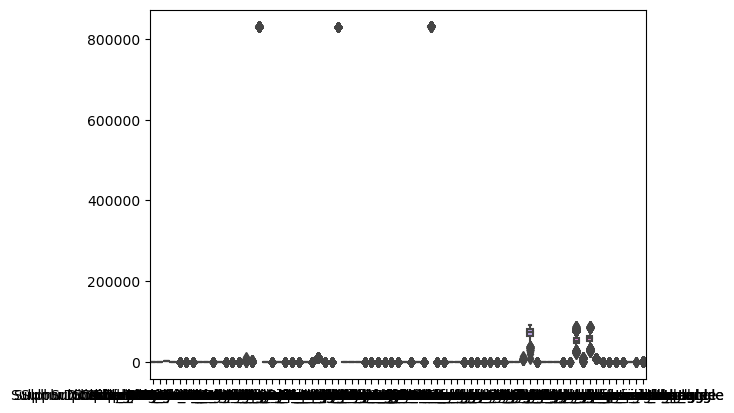

In [14]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


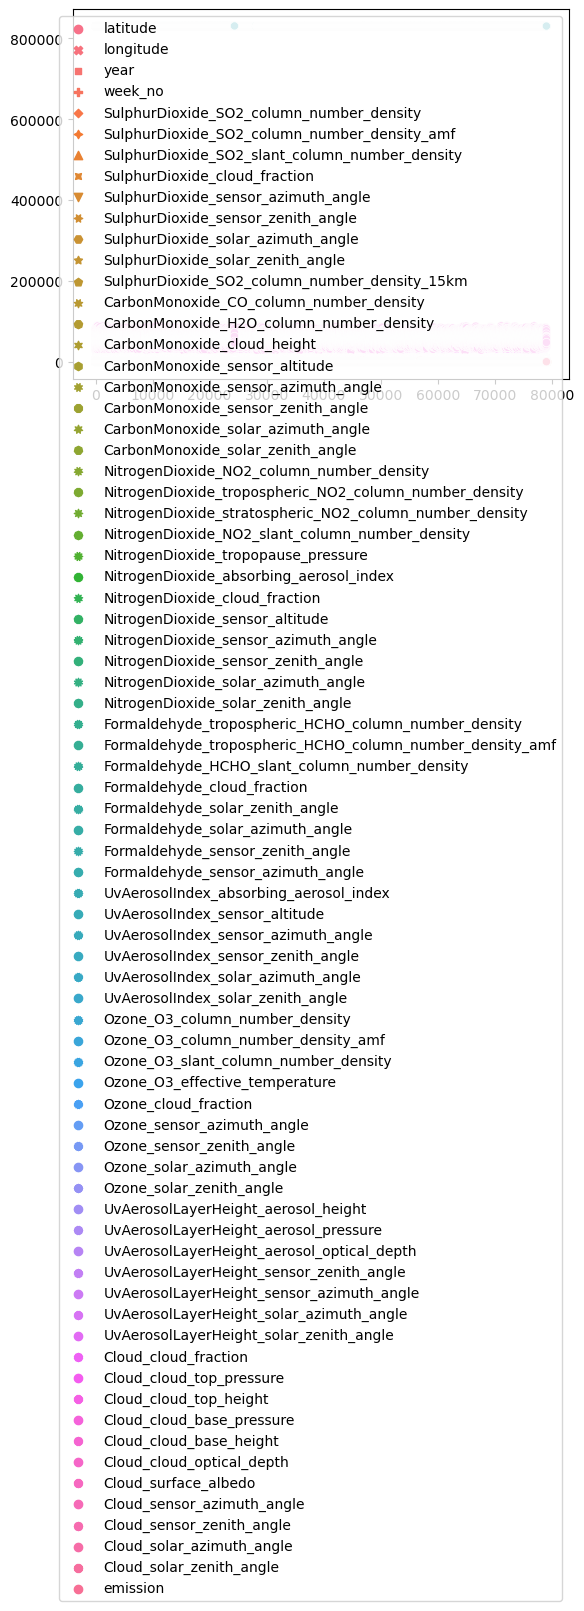

In [15]:
sns.scatterplot(combined)

In [16]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

/tmp/ipykernel_32/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_32/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)


latitude                                     1.148000
longitude                                    1.209000
year                                         2.000000
week_no                                     25.500000
SulphurDioxide_SO2_column_number_density     0.000251
                                              ...    
Cloud_sensor_azimuth_angle                  38.951720
Cloud_sensor_zenith_angle                    8.657592
Cloud_solar_azimuth_angle                   76.424457
Cloud_solar_zenith_angle                     6.911993
emission                                    99.751600
Length: 75, dtype: float64


/tmp/ipykernel_32/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [17]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [18]:
combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]


/tmp/ipykernel_32/2604026707.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]


In [19]:
combined_new.shape

(60043, 76)

In [20]:
cat_cols = combined.select_dtypes(include='object')

In [21]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)
    

ID_LAT_LON_YEAR_WEEK
ID_-0.510_29.290_2019_00    1
ID_-2.817_29.283_2020_14    1
ID_-2.817_29.283_2020_24    1
ID_-2.817_29.283_2020_23    1
ID_-2.817_29.283_2020_22    1
                           ..
ID_-1.753_28.547_2021_05    1
ID_-1.753_28.547_2021_04    1
ID_-1.753_28.547_2021_03    1
ID_-1.753_28.547_2021_02    1
ID_-3.299_30.301_2022_48    1
Name: ID_LAT_LON_YEAR_WEEK, Length: 103376, dtype: int64
__________________________________________________


In [22]:
num_cols = combined.select_dtypes(include='number')

In [25]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

latitude
-1.176    624
-2.049    624
-1.342    624
-1.911    416
-1.429    416
         ... 
-1.523    208
-1.516    208
-1.514    208
-1.505    208
-3.299    208
Name: latitude, Length: 452, dtype: int64
__________________________________________________
longitude
29.601    832
30.029    624
30.245    624
28.547    416
29.168    416
         ... 
29.614    208
29.314    208
30.618    208
29.350    208
30.301    208
Name: longitude, Length: 453, dtype: int64
__________________________________________________
year
2019    26341
2020    26341
2021    26341
2022    24353
Name: year, dtype: int64
__________________________________________________
week_no
0     1988
37    1988
27    1988
28    1988
29    1988
30    1988
31    1988
32    1988
33    1988
34    1988
35    1988
36    1988
38    1988
25    1988
39    1988
40    1988
41    1988
42    1988
43    1988
44    1988
45    1988
46    1988
47    1988
48    1988
1     1988
26    1988
24    1988
12    1988
2     1988
3     1988
4     1988


<Axes: >

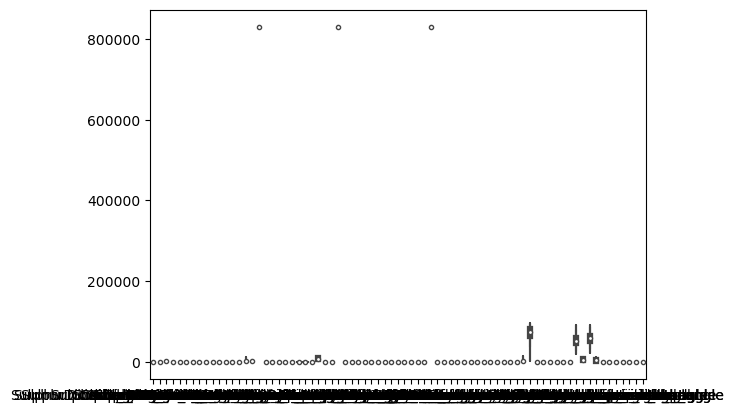

In [26]:
sns.violinplot(combined)

<Axes: >

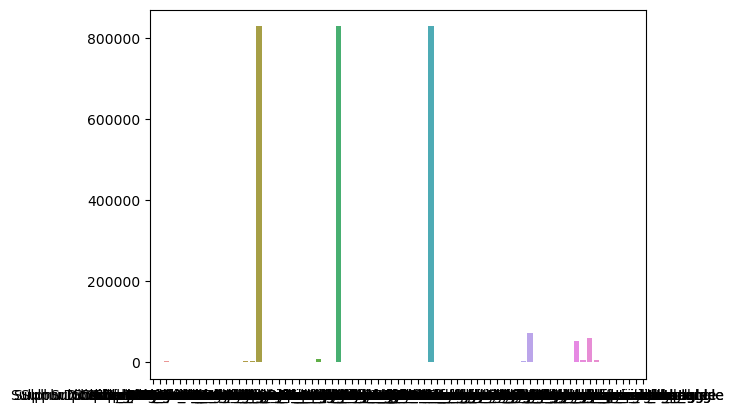

In [5]:
sns.barplot(combined)

/tmp/ipykernel_32/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

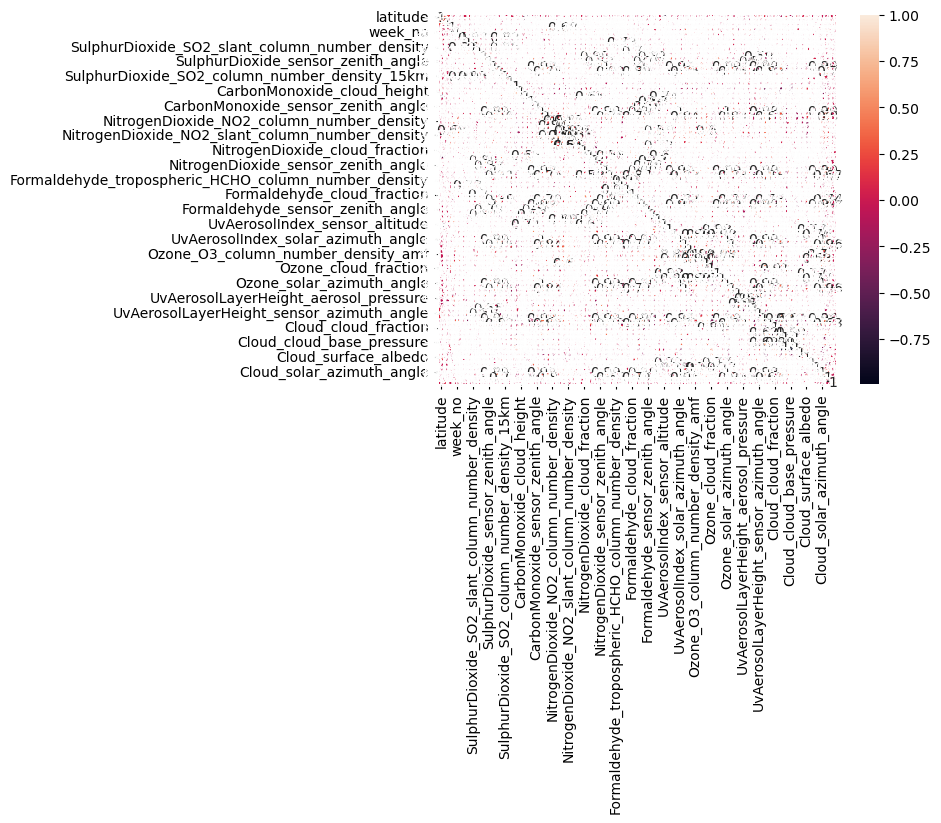

In [27]:
sns.heatmap(combined.corr(),annot=True)

In [ ]:
sns.lineplot(combined)

In [ ]:
sns.pairplot(combined)

<Axes: ylabel='Density'>

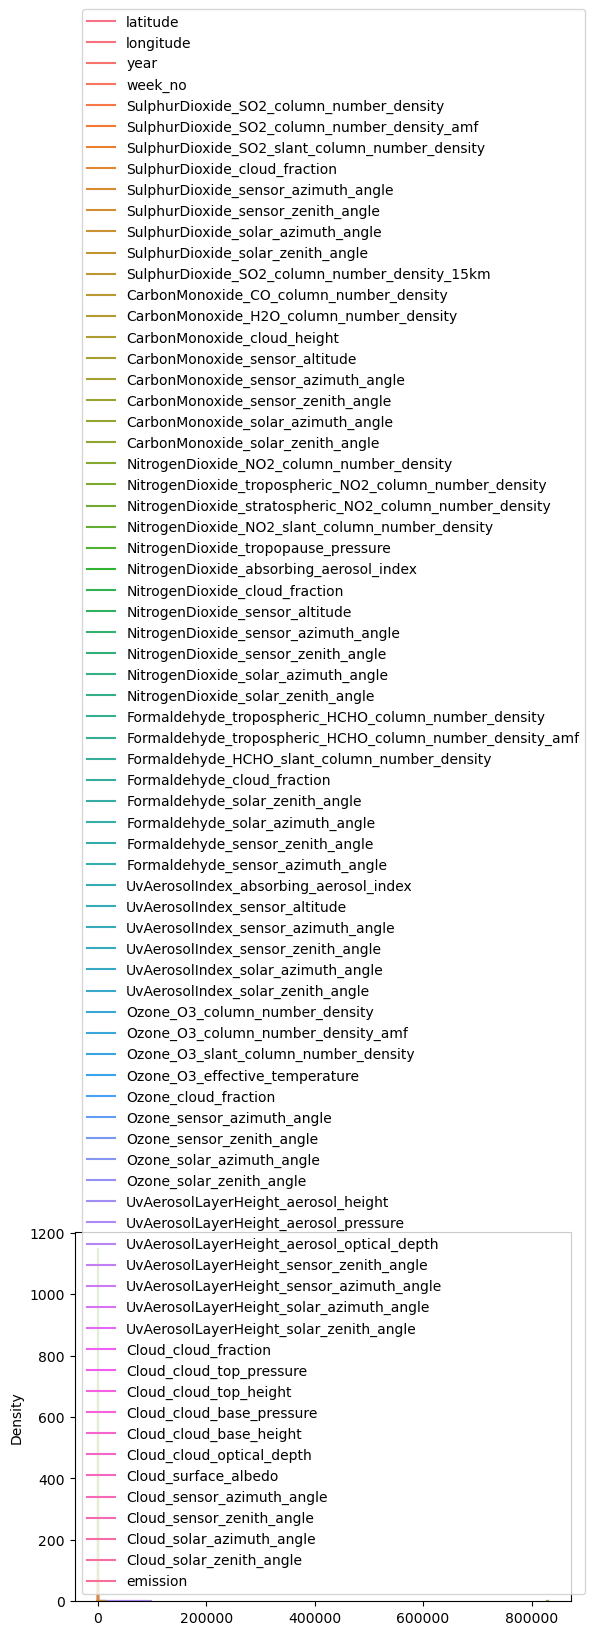

In [10]:
sns.kdeplot(combined)

In [32]:
combined['ID_LAT_LON_YEAR_WEEK']=combined['ID_LAT_LON_YEAR_WEEK'].map({'Good':2,'Standard':1,'Poor':0})

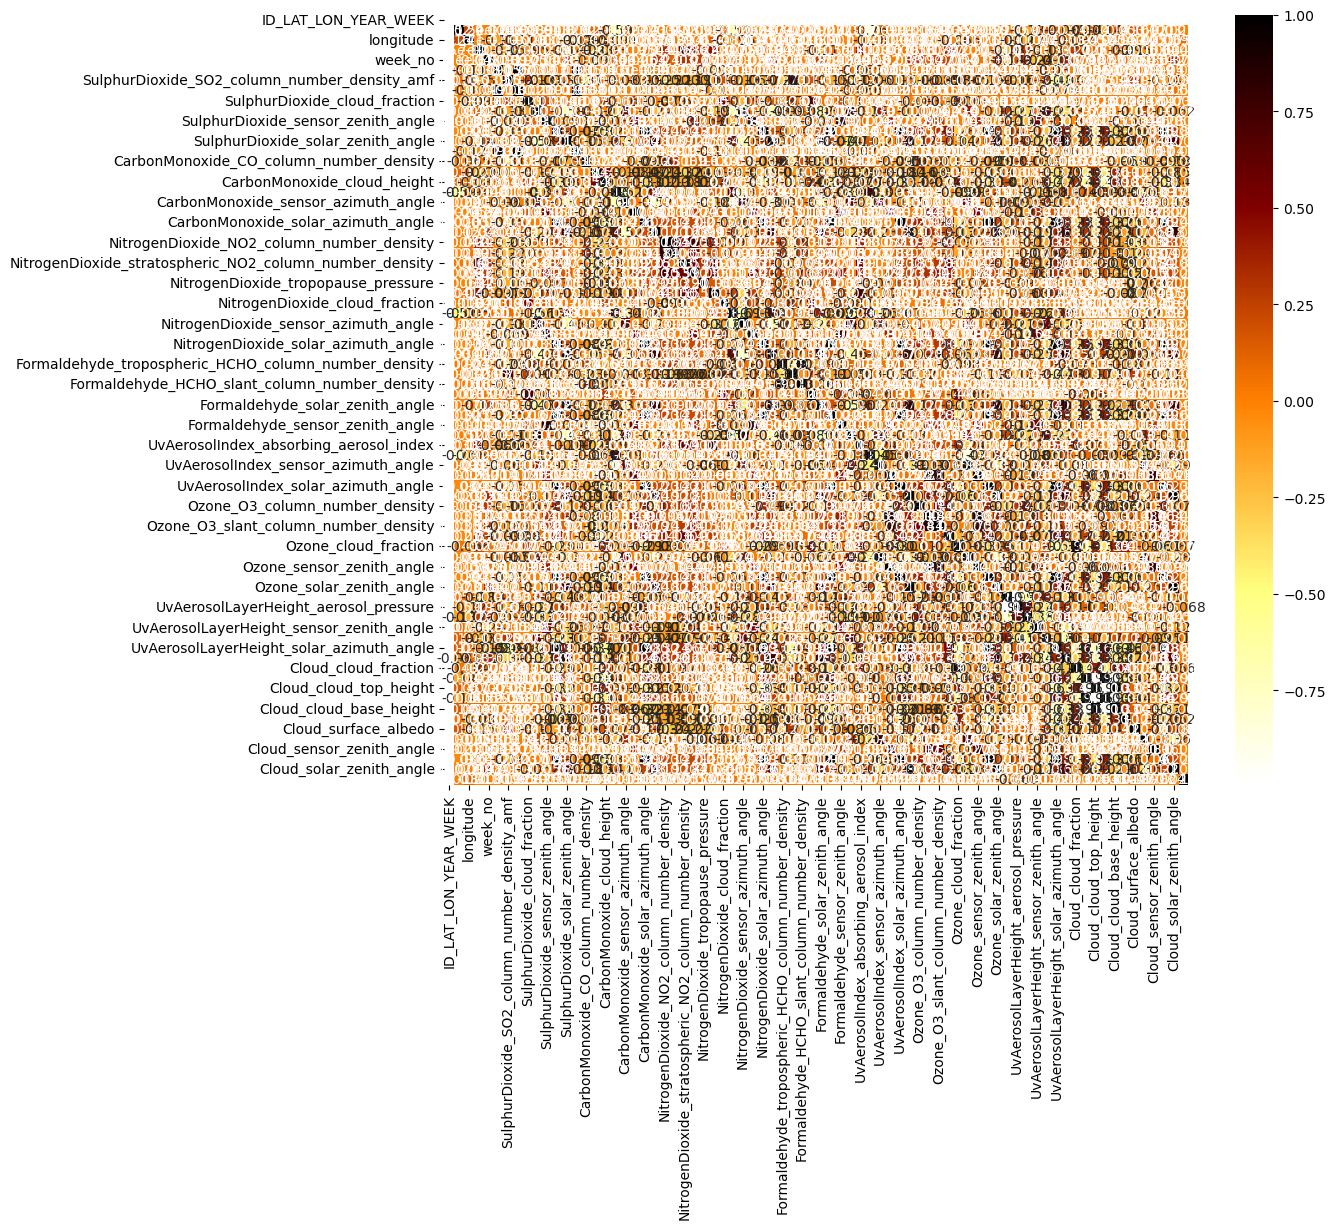

In [34]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

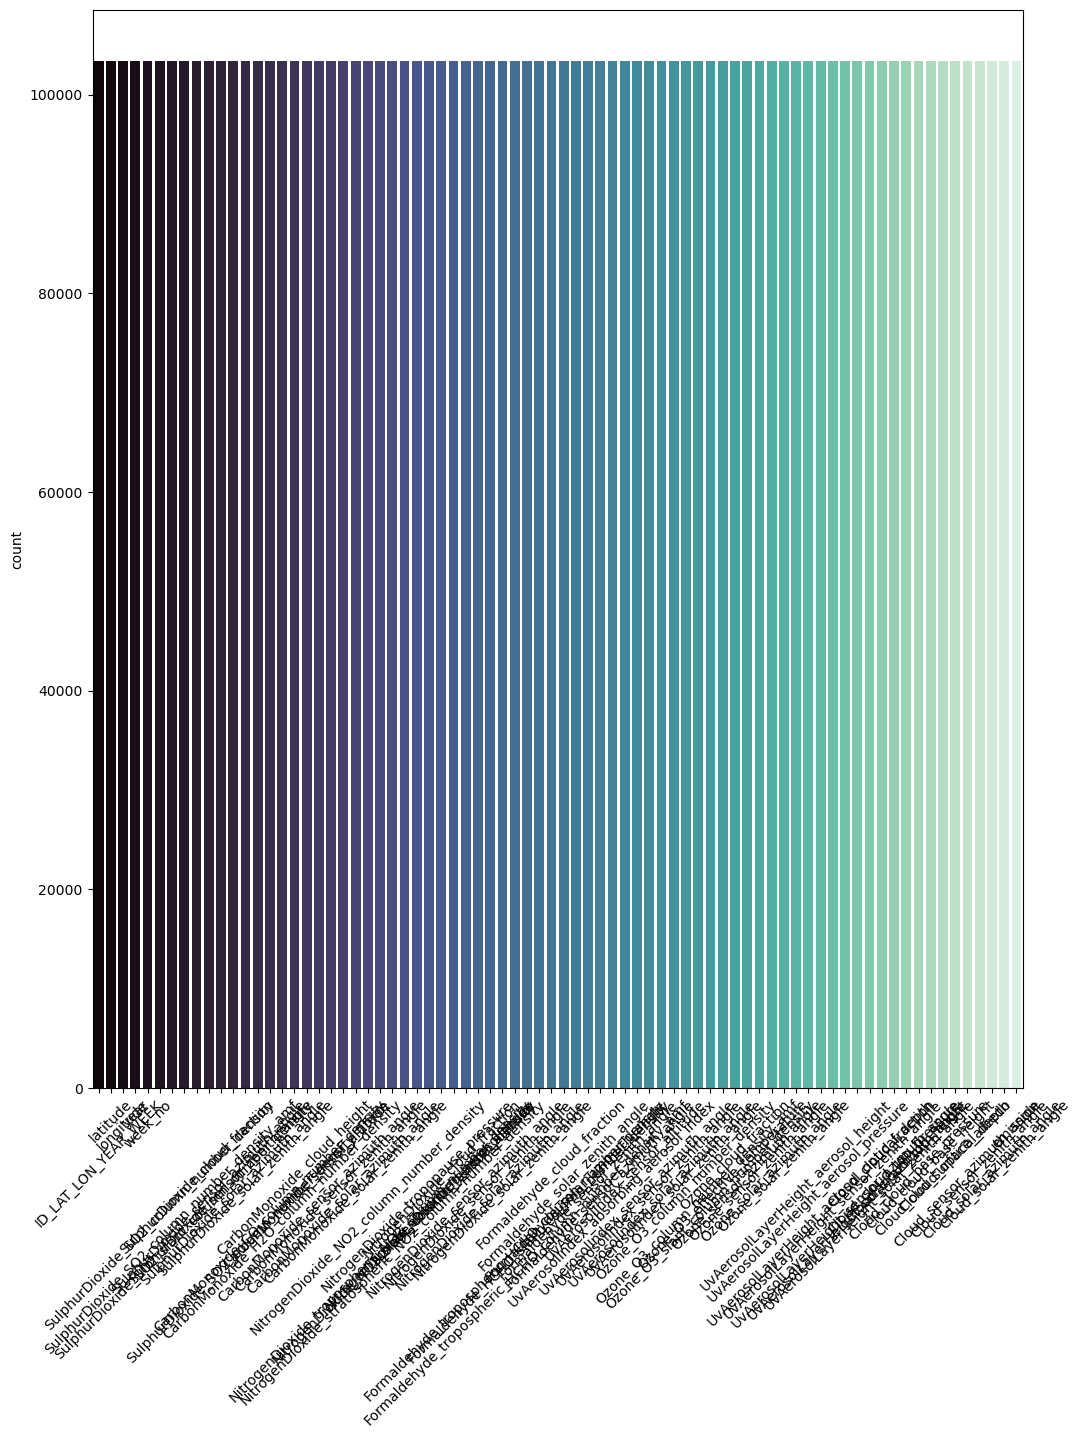

In [36]:
plt.figure(figsize=(12,14))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75]),
 [Text(0, 0, 'ID_LAT_LON_YEAR_WEEK'),
  Text(1, 0, 'latitude'),
  Text(2, 0, 'longitude'),
  Text(3, 0, 'year'),
  Text(4, 0, 'week_no'),
  Text(5, 0, 'SulphurDioxide_SO2_column_number_density'),
  Text(6, 0, 'SulphurDioxide_SO2_column_number_density_amf'),
  Text(7, 0, 'SulphurDioxide_SO2_slant_column_number_density'),
  Text(8, 0, 'SulphurDioxide_cloud_fraction'),
  Text(9, 0, 'SulphurDioxide_sensor_azimuth_angle'),
  Text(10, 0, 'SulphurDioxide_sensor_zenith_angle'),
  Text(11, 0, 'SulphurDioxide_solar_azimuth_angle'),
  Text(12, 0, 'SulphurDioxide_solar_zenith_angle'),
  Text(13, 0, 'SulphurDioxide_SO2_column_number_density_15km'),
  Text(14,

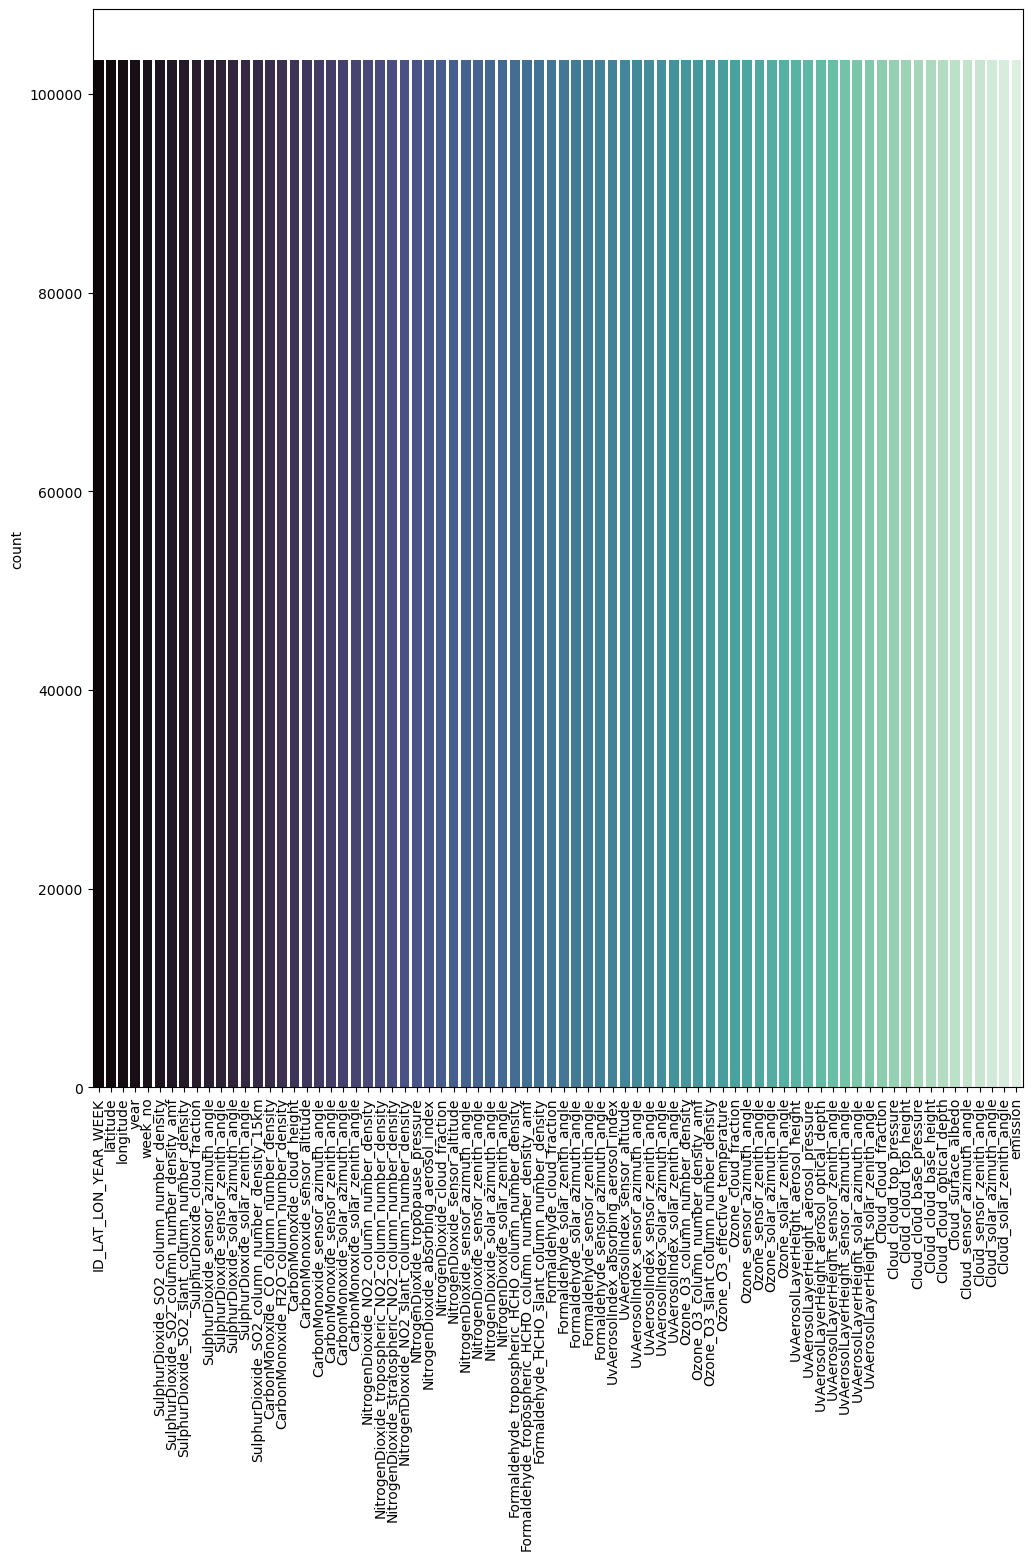

In [40]:
plt.figure(figsize=(12,14))
sns.countplot(data=combined,palette='mako')
plt.xticks(rotation=90)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


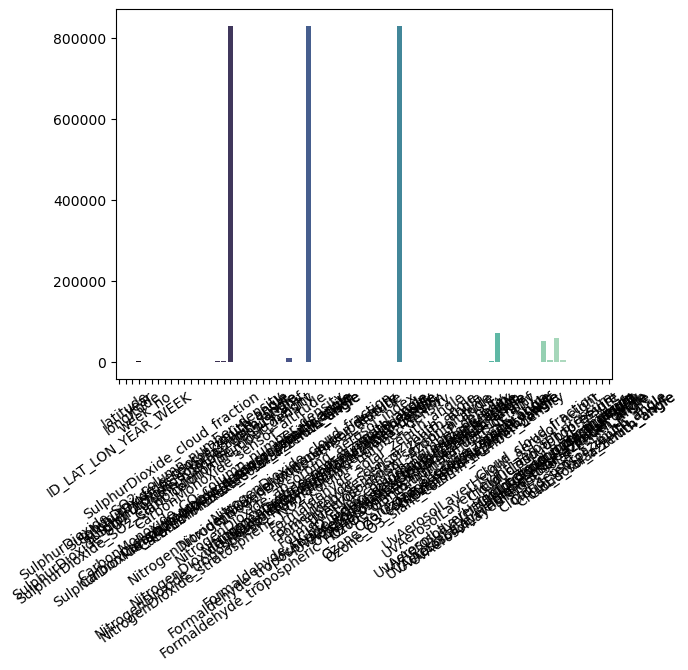

In [42]:
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=35);

latitude




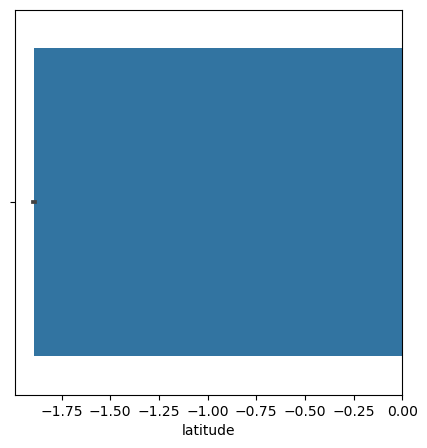

longitude




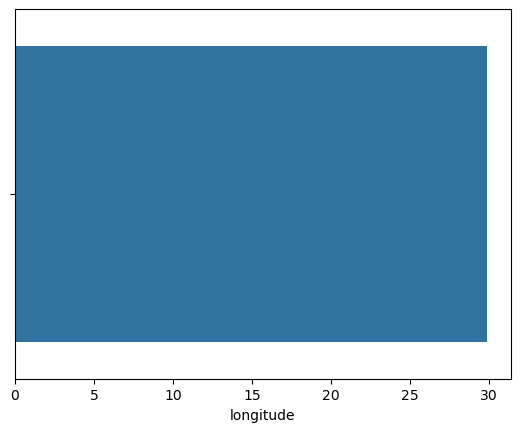

year




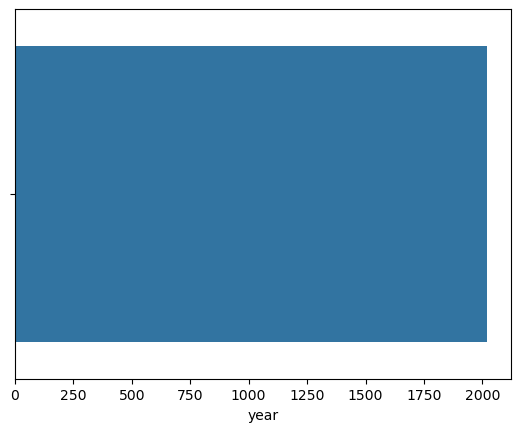

week_no




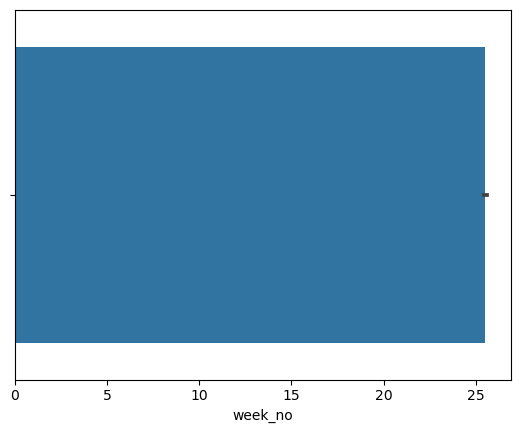

SulphurDioxide_SO2_column_number_density




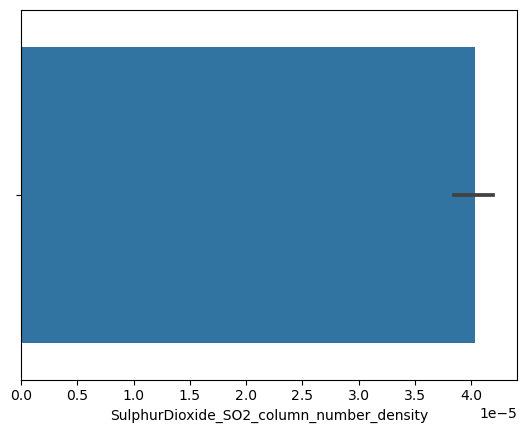

SulphurDioxide_SO2_column_number_density_amf




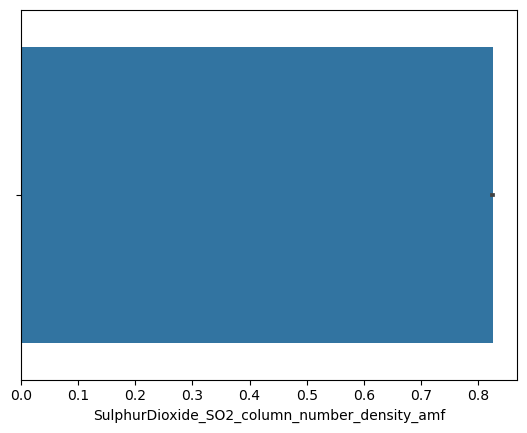

SulphurDioxide_SO2_slant_column_number_density




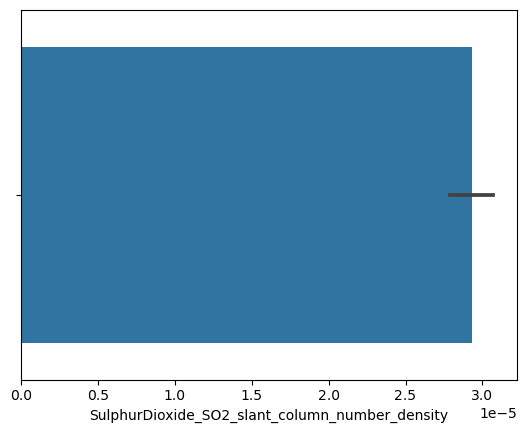

SulphurDioxide_cloud_fraction




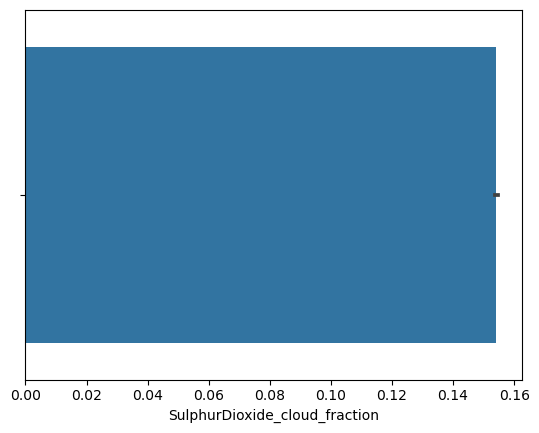

SulphurDioxide_sensor_azimuth_angle




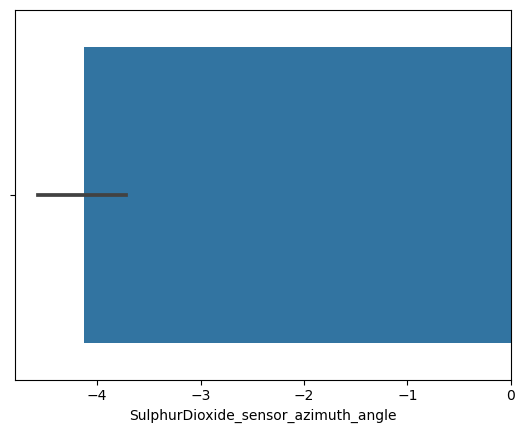

SulphurDioxide_sensor_zenith_angle




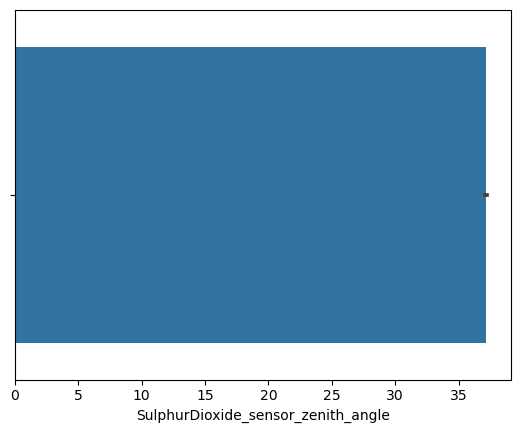

SulphurDioxide_solar_azimuth_angle




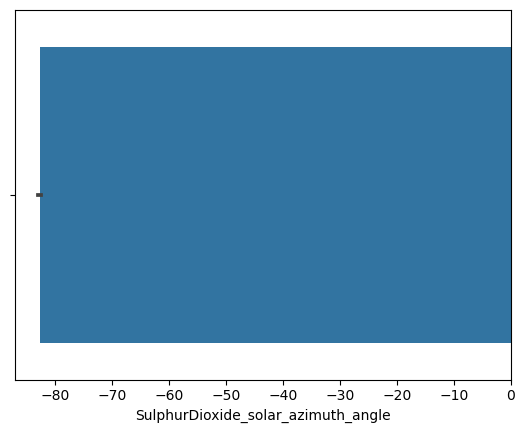

SulphurDioxide_solar_zenith_angle




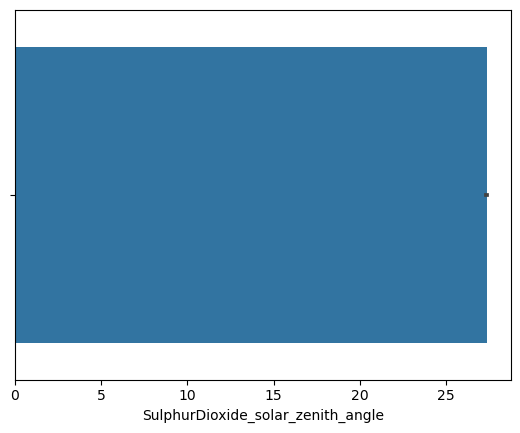

SulphurDioxide_SO2_column_number_density_15km




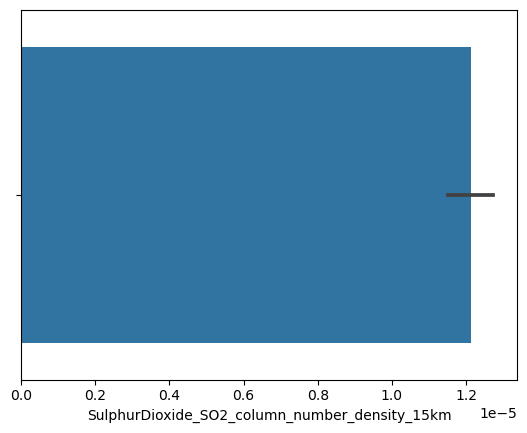

CarbonMonoxide_CO_column_number_density




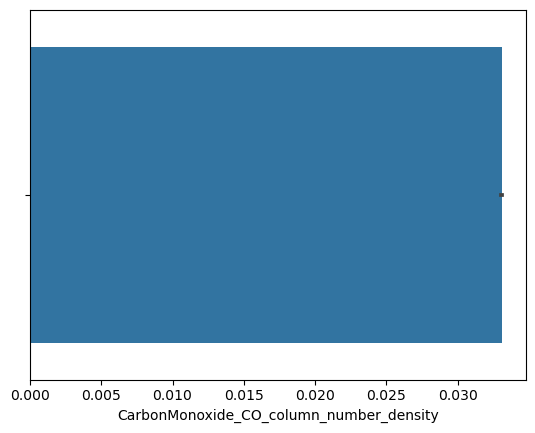

CarbonMonoxide_H2O_column_number_density




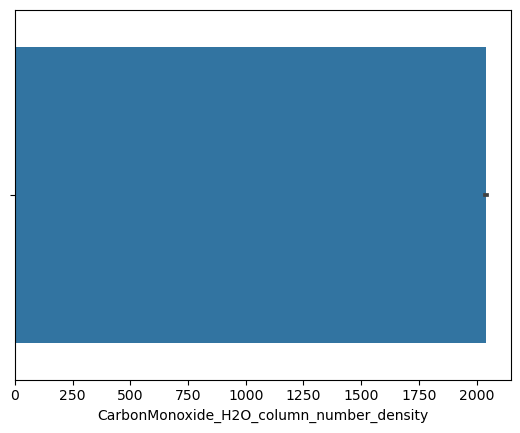

CarbonMonoxide_cloud_height




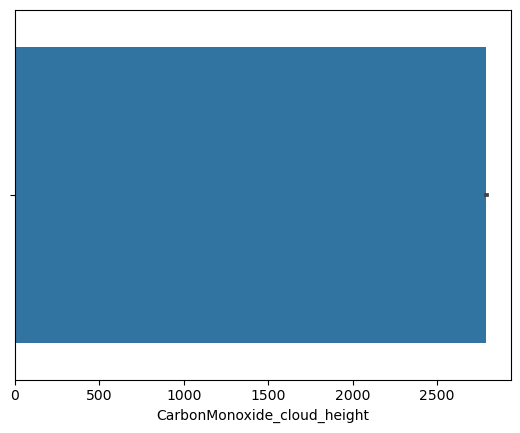

CarbonMonoxide_sensor_altitude




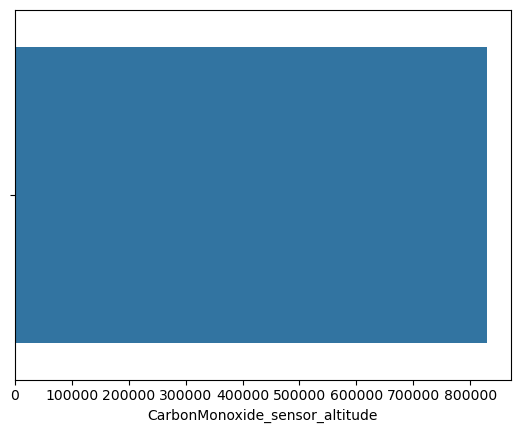

CarbonMonoxide_sensor_azimuth_angle




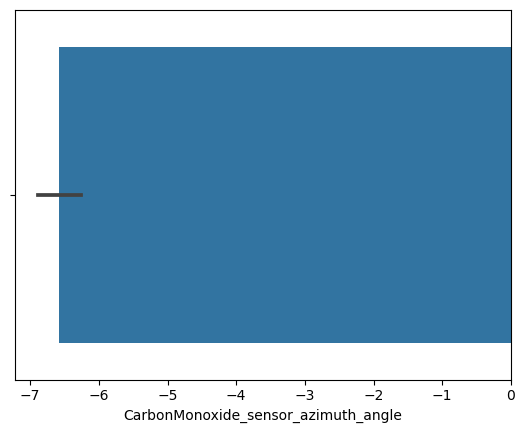

CarbonMonoxide_sensor_zenith_angle




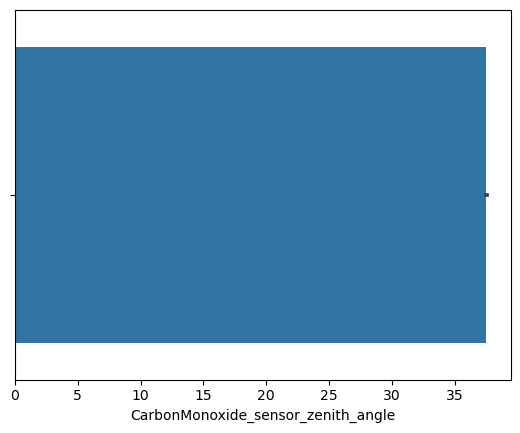

CarbonMonoxide_solar_azimuth_angle




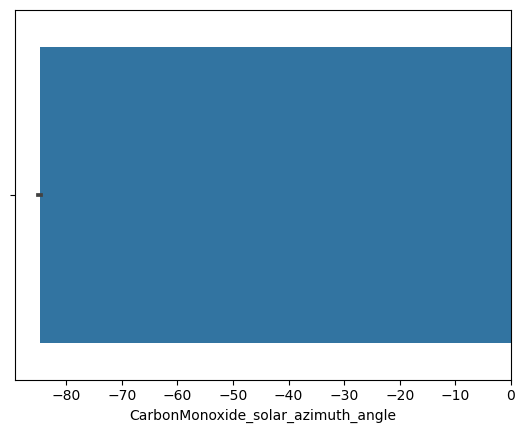

CarbonMonoxide_solar_zenith_angle




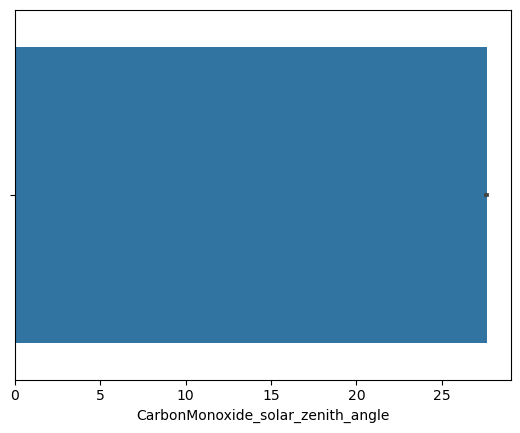

NitrogenDioxide_NO2_column_number_density




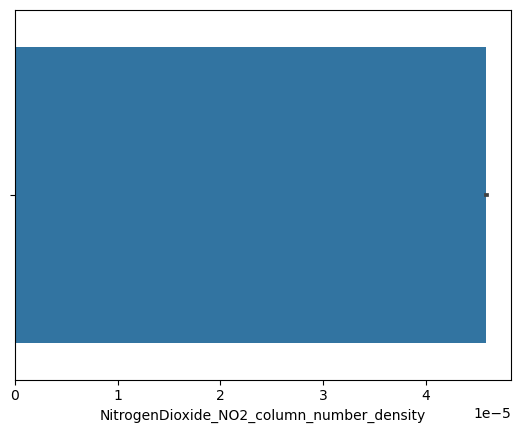

NitrogenDioxide_tropospheric_NO2_column_number_density




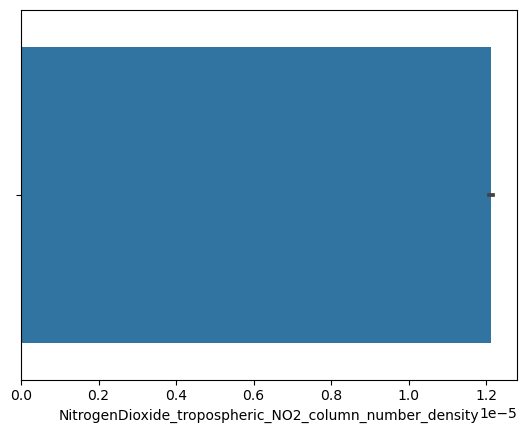

NitrogenDioxide_stratospheric_NO2_column_number_density




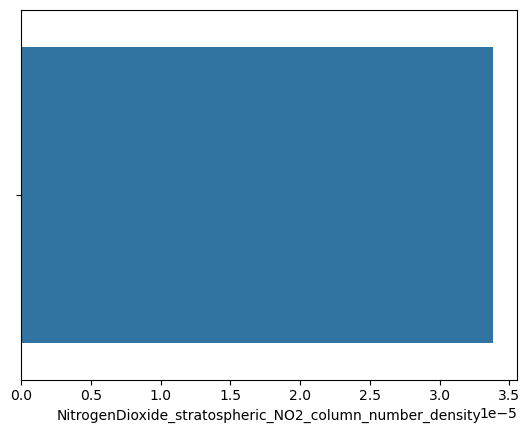

NitrogenDioxide_NO2_slant_column_number_density




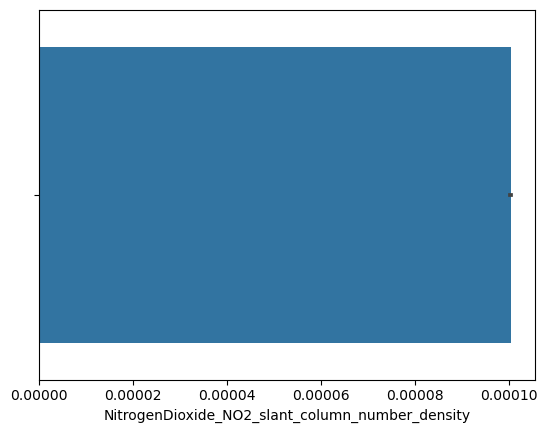

NitrogenDioxide_tropopause_pressure




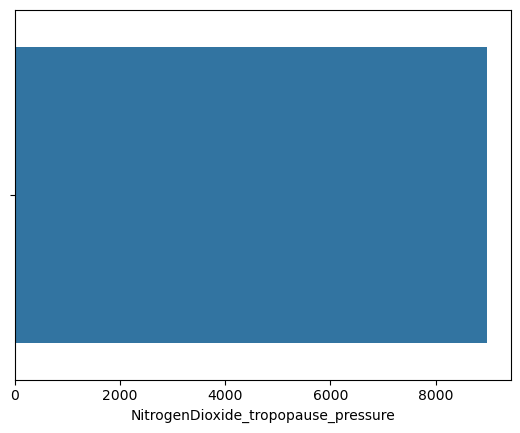

NitrogenDioxide_absorbing_aerosol_index




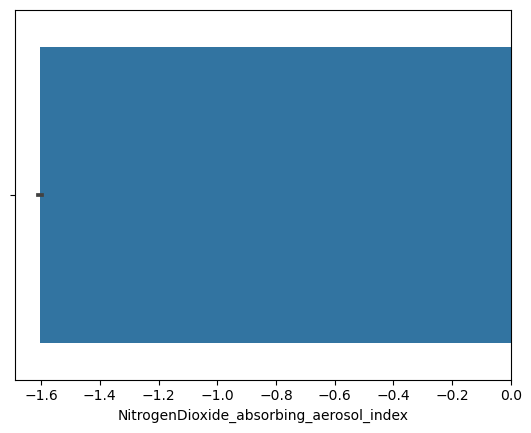

NitrogenDioxide_cloud_fraction




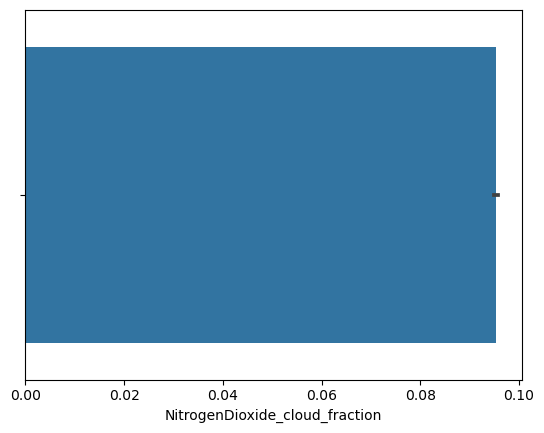

NitrogenDioxide_sensor_altitude




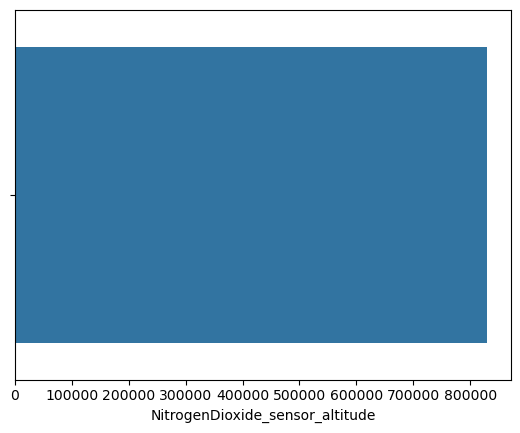

NitrogenDioxide_sensor_azimuth_angle




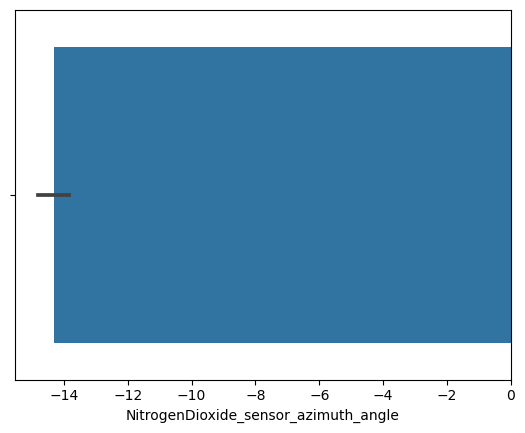

NitrogenDioxide_sensor_zenith_angle




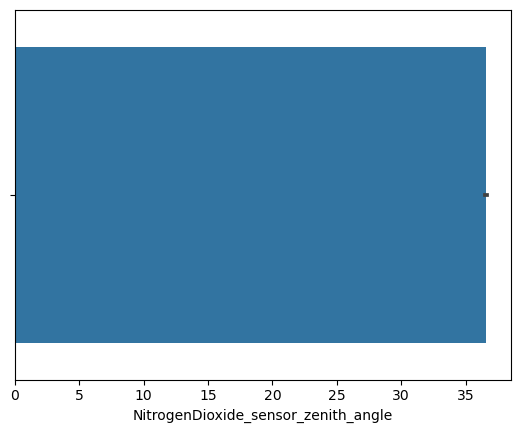

NitrogenDioxide_solar_azimuth_angle




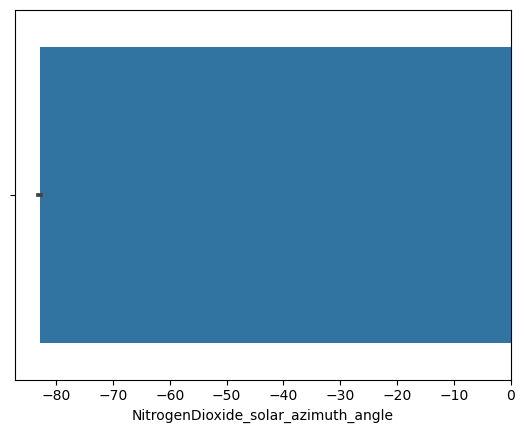

NitrogenDioxide_solar_zenith_angle




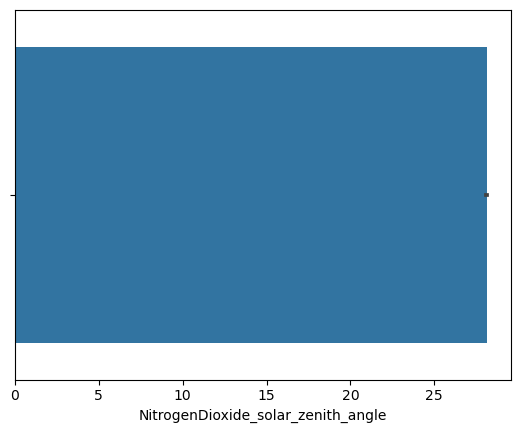

Formaldehyde_tropospheric_HCHO_column_number_density




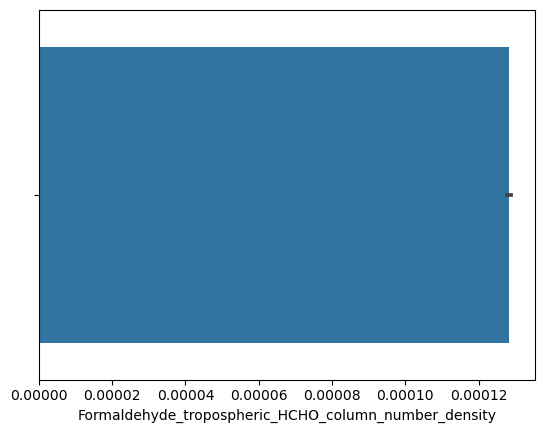

Formaldehyde_tropospheric_HCHO_column_number_density_amf




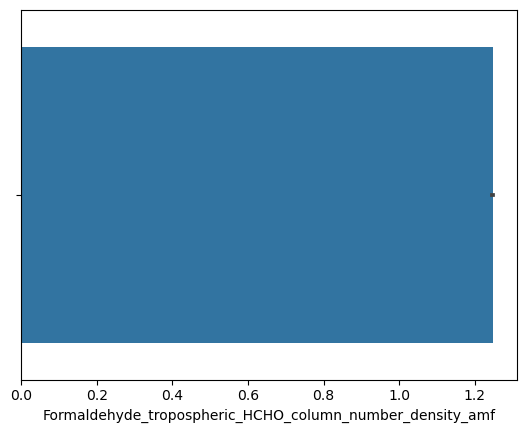

Formaldehyde_HCHO_slant_column_number_density




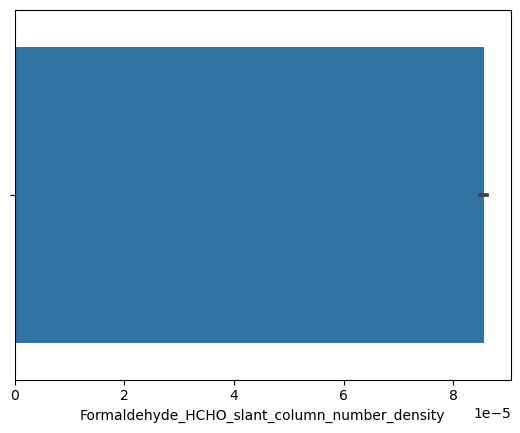

Formaldehyde_cloud_fraction




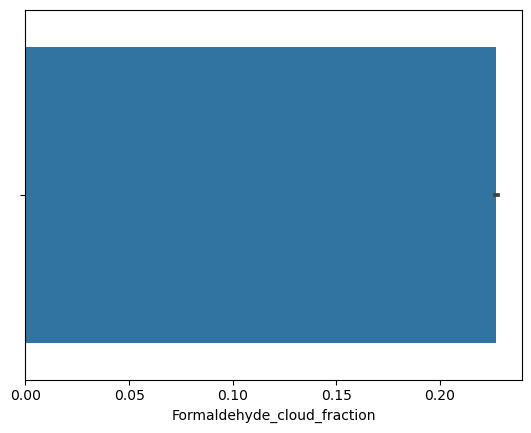

Formaldehyde_solar_zenith_angle




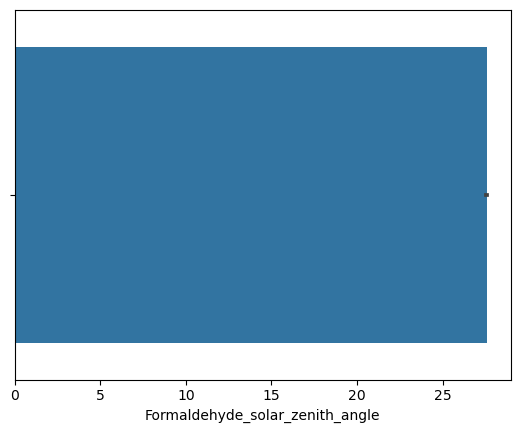

Formaldehyde_solar_azimuth_angle




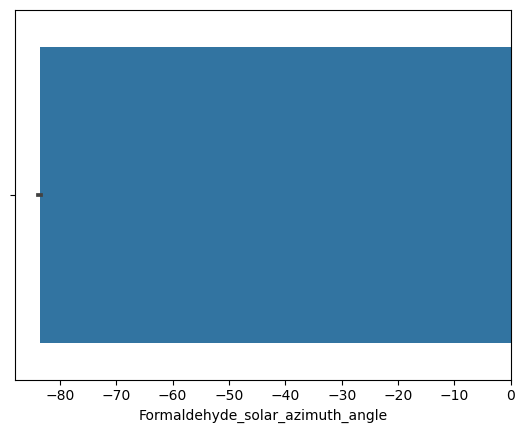

Formaldehyde_sensor_zenith_angle




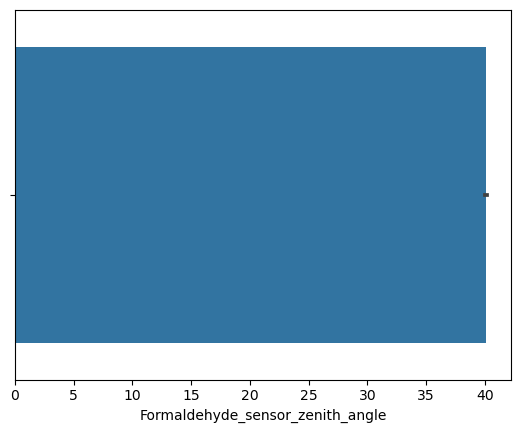

Formaldehyde_sensor_azimuth_angle




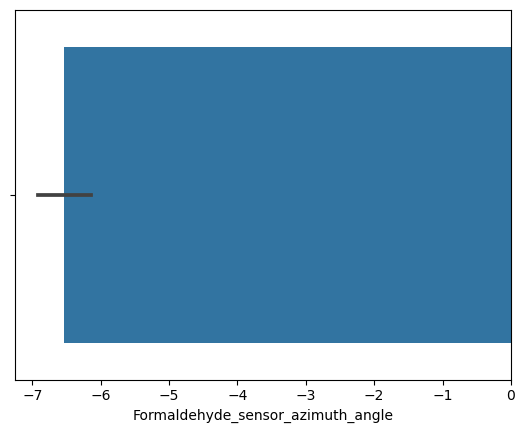

UvAerosolIndex_absorbing_aerosol_index




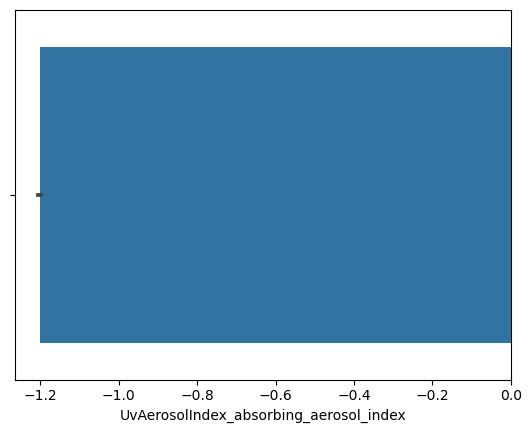

UvAerosolIndex_sensor_altitude




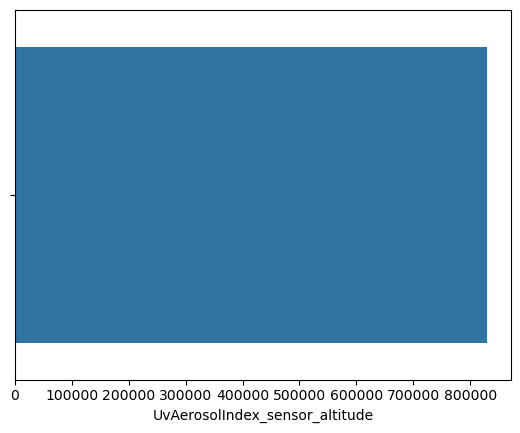

UvAerosolIndex_sensor_azimuth_angle




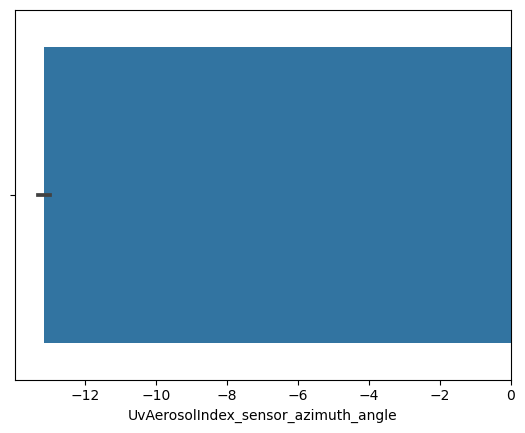

UvAerosolIndex_sensor_zenith_angle




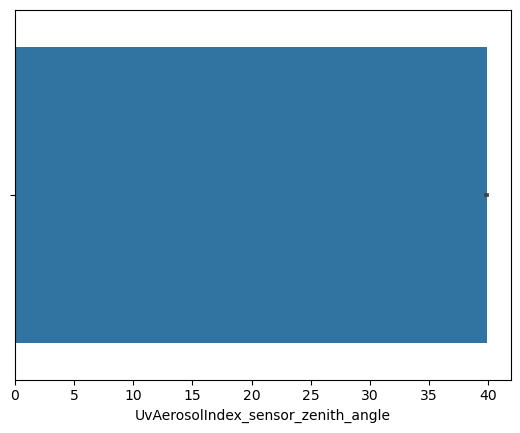

UvAerosolIndex_solar_azimuth_angle




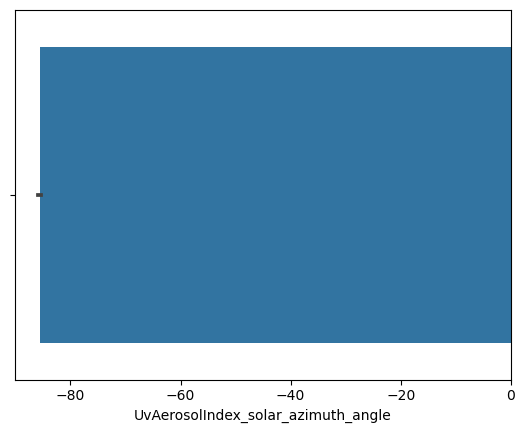

UvAerosolIndex_solar_zenith_angle




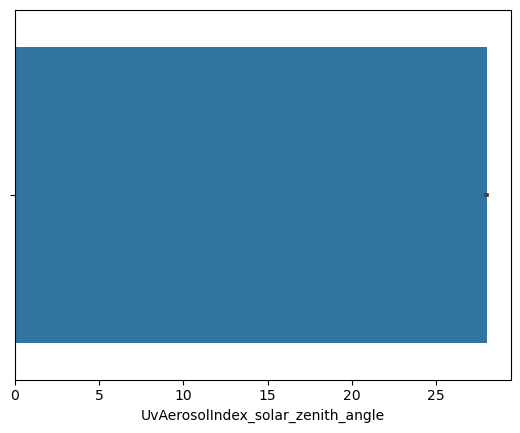

Ozone_O3_column_number_density




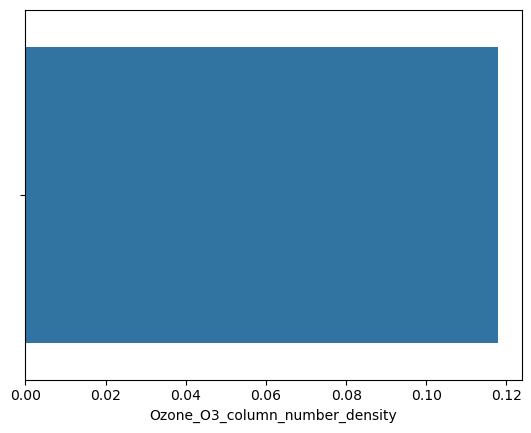

Ozone_O3_column_number_density_amf




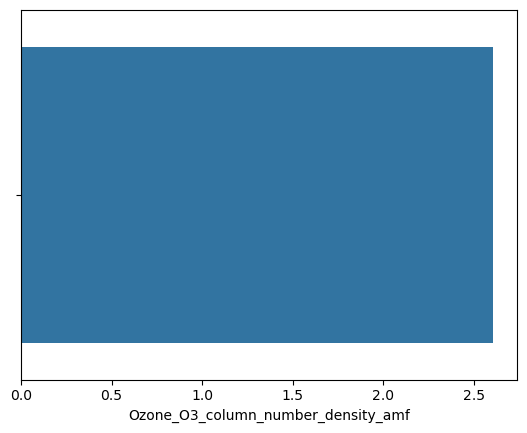

Ozone_O3_slant_column_number_density




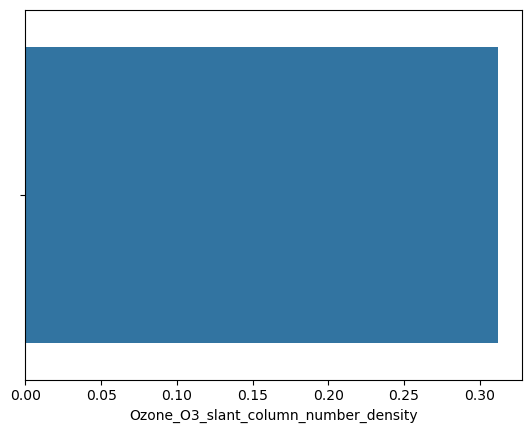

Ozone_O3_effective_temperature




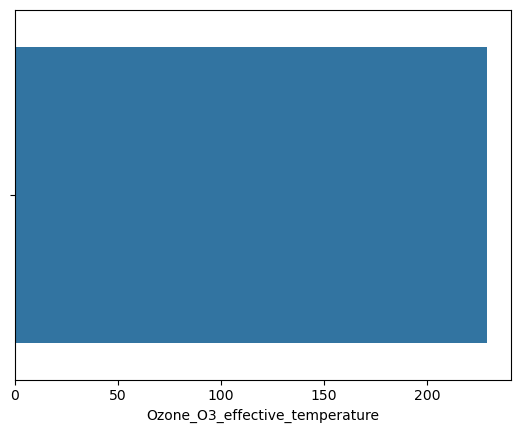

Ozone_cloud_fraction




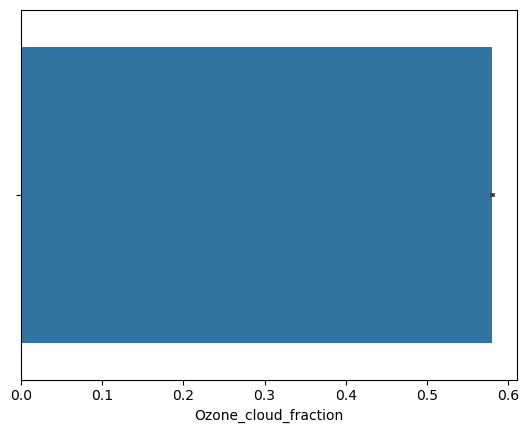

Ozone_sensor_azimuth_angle




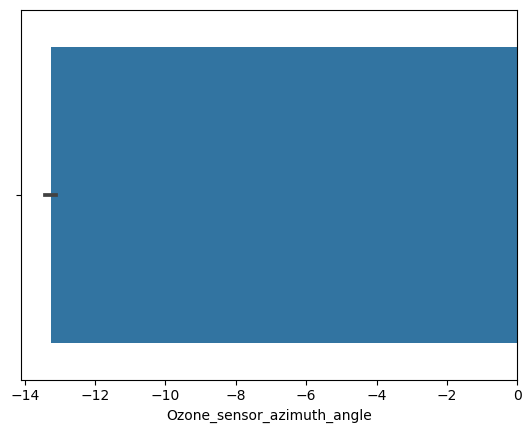

Ozone_sensor_zenith_angle




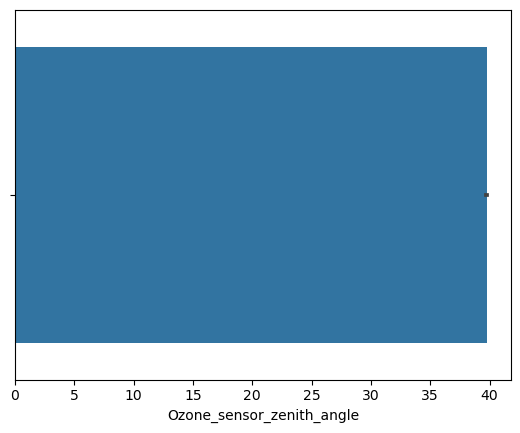

Ozone_solar_azimuth_angle




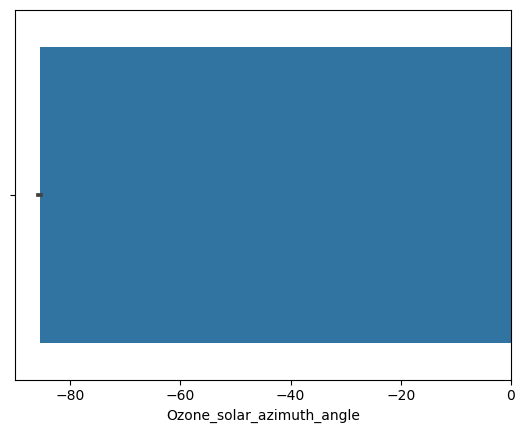

Ozone_solar_zenith_angle




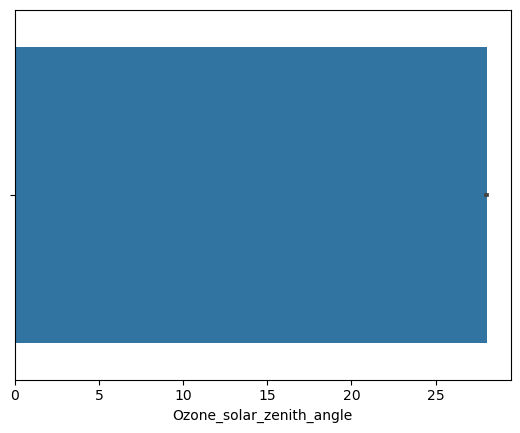

UvAerosolLayerHeight_aerosol_height




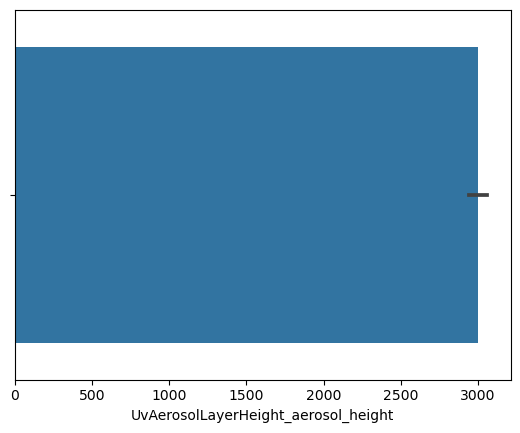

UvAerosolLayerHeight_aerosol_pressure




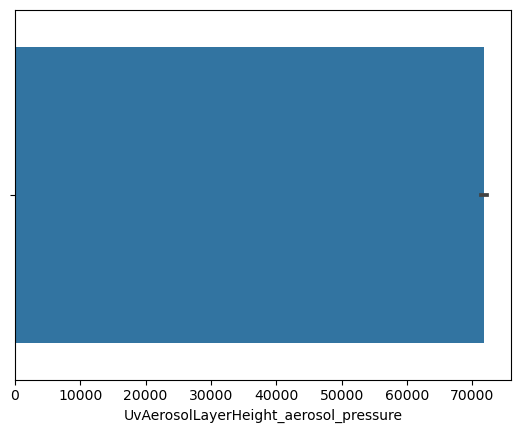

UvAerosolLayerHeight_aerosol_optical_depth




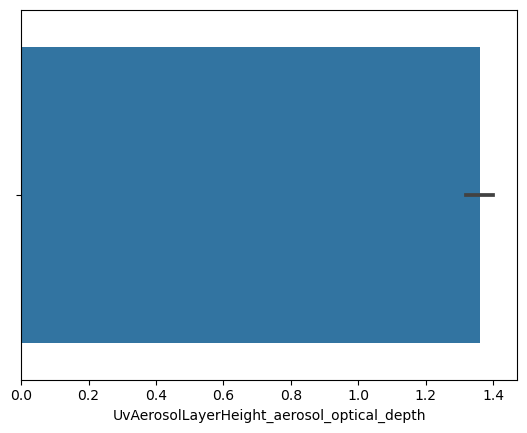

UvAerosolLayerHeight_sensor_zenith_angle




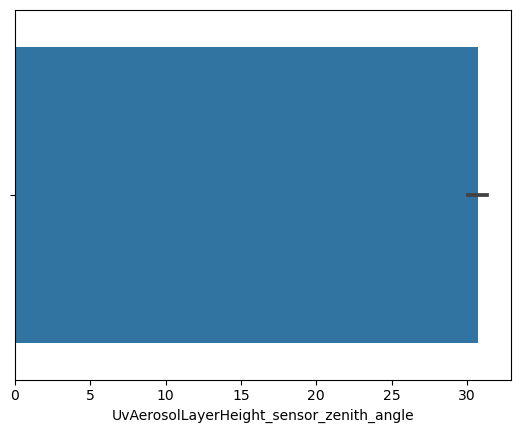

UvAerosolLayerHeight_sensor_azimuth_angle




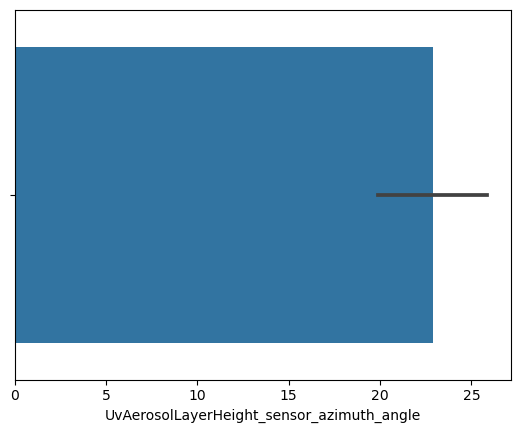

UvAerosolLayerHeight_solar_azimuth_angle




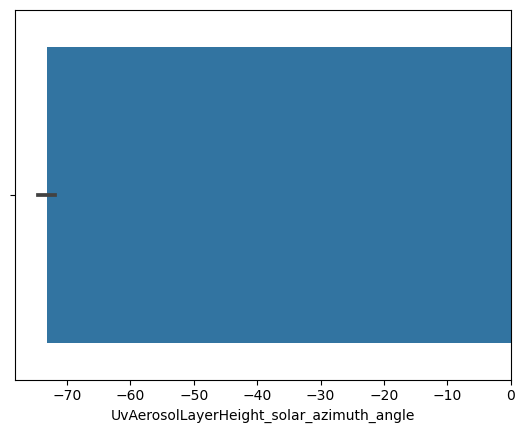

UvAerosolLayerHeight_solar_zenith_angle




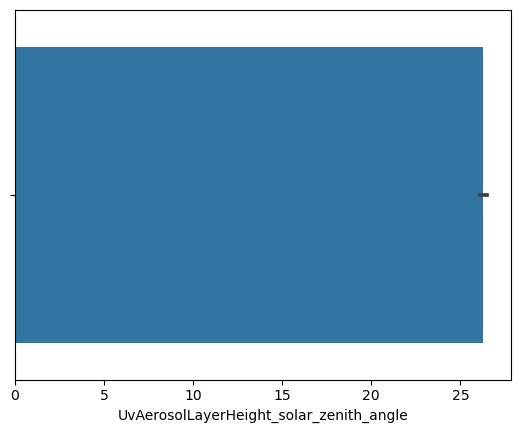

Cloud_cloud_fraction




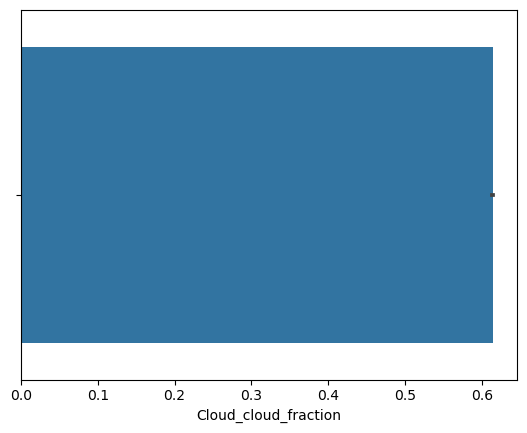

Cloud_cloud_top_pressure




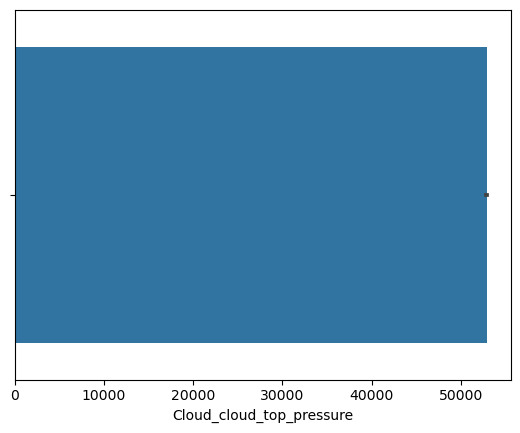

Cloud_cloud_top_height




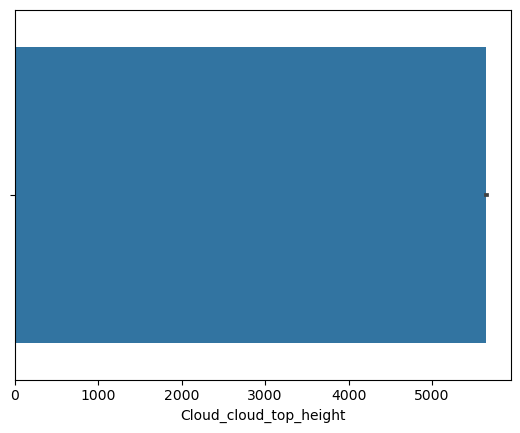

Cloud_cloud_base_pressure




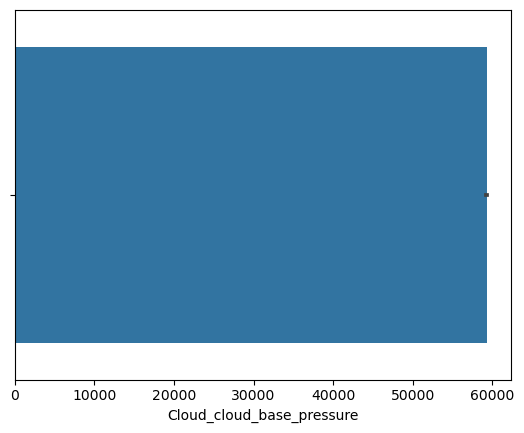

Cloud_cloud_base_height




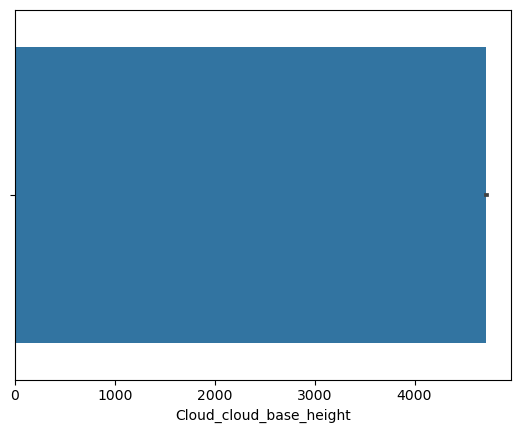

Cloud_cloud_optical_depth




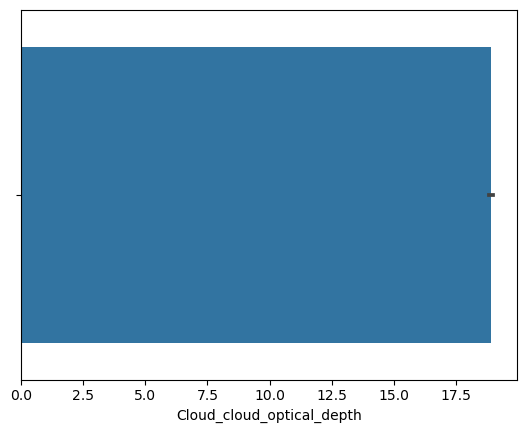

Cloud_surface_albedo




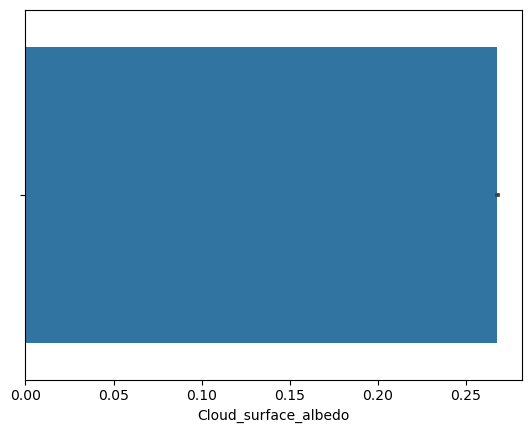

Cloud_sensor_azimuth_angle




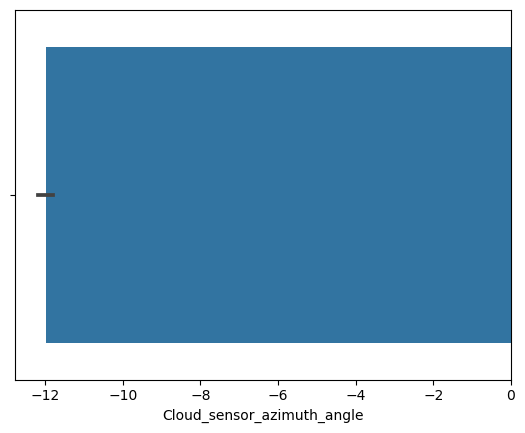

Cloud_sensor_zenith_angle




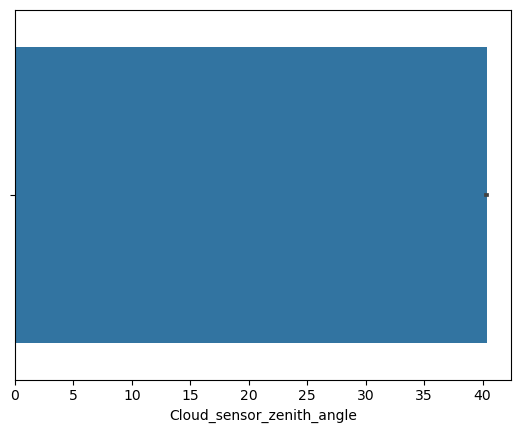

Cloud_solar_azimuth_angle




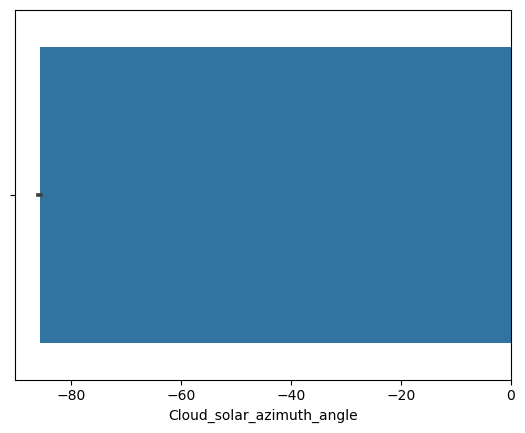

Cloud_solar_zenith_angle




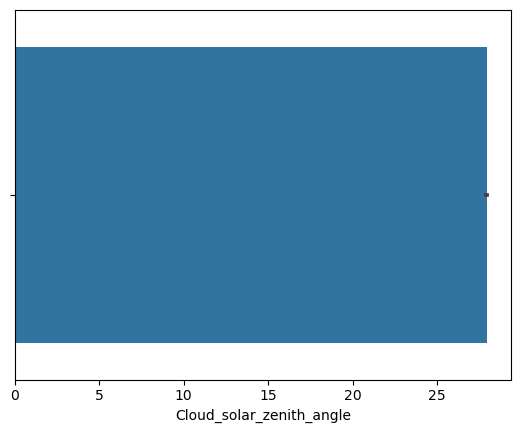

emission




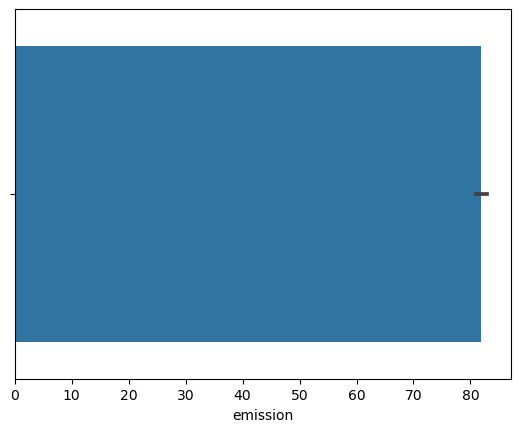

In [45]:
x=i
plt.figure(figsize=(5,5))
for i in num_cols:
    print(i)
    sns.barplot(data=combined,x=i)
    print('\n')
    plt.show()

In [47]:
combined.isnull().sum()/len(combined)*100

ID_LAT_LON_YEAR_WEEK          100.000000
latitude                        0.000000
longitude                       0.000000
year                            0.000000
week_no                         0.000000
                                 ...    
Cloud_sensor_azimuth_angle      0.628773
Cloud_sensor_zenith_angle       0.628773
Cloud_solar_azimuth_angle       0.628773
Cloud_solar_zenith_angle        0.628773
emission                       23.557692
Length: 76, dtype: float64

In [49]:
combined.head()

,ID_LAT_LON_YEAR_WEEK,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,SulphurDioxide_sensor_zenith_angle,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_solar_zenith_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,CarbonMonoxide_cloud_height,CarbonMonoxide_sensor_altitude,CarbonMonoxide_sensor_azimuth_angle,CarbonMonoxide_sensor_zenith_angle,CarbonMonoxide_solar_azimuth_angle,CarbonMonoxide_solar_zenith_angle,NitrogenDioxide_NO2_column_number_density,NitrogenDioxide_tropospheric_NO2_column_number_density,NitrogenDioxide_stratospheric_NO2_column_number_density,NitrogenDioxide_NO2_slant_column_number_density,NitrogenDioxide_tropopause_pressure,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_sensor_altitude,NitrogenDioxide_sensor_azimuth_angle,NitrogenDioxide_sensor_zenith_angle,NitrogenDioxide_solar_azimuth_angle,NitrogenDioxide_solar_zenith_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_cloud_fraction,Formaldehyde_solar_zenith_angle,Formaldehyde_solar_azimuth_angle,Formaldehyde_sensor_zenith_angle,Formaldehyde_sensor_azimuth_angle,UvAerosolIndex_absorbing_aerosol_index,UvAerosolIndex_sensor_altitude,UvAerosolIndex_sensor_azimuth_angle,UvAerosolIndex_sensor_zenith_angle,UvAerosolIndex_solar_azimuth_angle,UvAerosolIndex_solar_zenith_angle,Ozone_O3_column_number_density,Ozone_O3_column_number_density_amf,Ozone_O3_slant_column_number_density,Ozone_O3_effective_temperature,Ozone_cloud_fraction,Ozone_sensor_azimuth_angle,Ozone_sensor_zenith_angle,Ozone_solar_azimuth_angle,Ozone_solar_zenith_angle,UvAerosolLayerHeight_aerosol_height,UvAerosolLayerHeight_aerosol_pressure,UvAerosolLayerHeight_aerosol_optical_depth,UvAerosolLayerHeight_sensor_zenith_angle,UvAerosolLayerHeight_sensor_azimuth_angle,UvAerosolLayerHeight_solar_azimuth_angle,UvAerosolLayerHeight_solar_zenith_angle,Cloud_cloud_fraction,Cloud_cloud_top_pressure,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle,emission
0,NaN,-0.51,29.29,2019,0,-0.000108,0.603019,-0.000065,0.255668,-98.593887,50.843559,-130.050797,35.874496,-0.000027,0.035370,1589.024536,4061.098145,829530.500000,71.111977,52.775928,-149.875565,25.965214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000117,0.863230,0.000038,0.255668,35.874496,-130.050797,50.843559,-98.593887,-1.280761,829864.546875,-12.628979,35.632416,-138.786446,30.752128,0.115927,2.506609,0.295663,225.731144,0.595473,-12.628979,35.632416,-138.786446,30.752128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.595473,53534.732422,3664.436218,61085.809570,2615.120483,15.568533,0.272292,-12.628986,35.632416,-138.786423,30.752140,3.750994
1,NaN,-0.51,29.29,2019,1,0.000021,0.728214,0.000014,0.130988,16.592861,39.137194,-140.874435,28.965133,0.000012,0.036526,1772.574405,1869.040414,829787.287130,-1.019594,38.982368,-140.158048,29.562000,0.000047,1.639765e-05,0.00003,0.000093,7311.869141,-1.935386,0.067038,829859.960368,5.471037,35.265195,-138.343908,30.054262,0.000170,1.172826,0.000143,0.200754,29.071781,-141.814827,43.050213,4.678839,-1.548119,829747.856973,16.152492,43.485327,-142.786141,28.573627,0.116775,2.657704,0.315733,226.172170,0.175166,24.464335,42.596541,-143.097868,28.213655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.213608,63790.296241,3651.190311,66969.478735,3174.572424,8.690601,0.256830,30.359375,39.557633,-145.183930,27.251779,4.025176
2,NaN,-0.51,29.29,2019,2,0.000514,0.748199,0.000385,0.110018,72.795837,52.868816,-150.191757,23.206415,0.000154,0.035338,2703.2

In [51]:
combined['ID_LAT_LON_YEAR_WEEK'].value_counts()

Series([], Name: ID_LAT_LON_YEAR_WEEK, dtype: int64)

In [54]:
combined['ID_LAT_LON_YEAR_WEEK'].unique()

array([nan])